# Table of contents

* **Introduction**
* **Objective**
* **Perceptron Foundations**
* **Data dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture, Model Building, and Model Training (Keras)
    * Model Architecture, Model Building, and Model Training (TensorFlow custom functions)
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

The Perceptron, the foundational element of neural networks, can be adapted from its original role as a binary classifier to perform regression by utilizing a continuous loss function and an identity activation in the output layer. This tutorial project focuses on predicting continuous medical insurance charges from a multi-feature dataset. The implementation utilizes Keras and TensorFlow, including the definition of custom loss functions, custom metrics, and a custom Perceptron layer to build the model from first principles. The exercise demonstrates the core mechanics of a simple neural network and its limitations when applied to a complex, real-world regression task.

# Objective

The main objective of this project is to achieve a comprehensive understanding of foundational deep learning concepts through hands-on implementation:

- To successfully define and train a single-layer Perceptron model, explicitly constructing the layer's operation using a Keras Layer subclass.
- To demonstrate the full machine learning pipeline, including essential preprocessing and dimensionality reduction steps.
- To visually illustrate the model's learned function—the regression hyperplane—and interpret its geometric relationship to the data.
- To establish a clear baseline performance against which more complex non-linear models (like Multi-Layer Perceptrons) can be compared.

# Perceptron Foundations

The Perceptron is the simplest and foundational structure of an artificial neural network. When adapted for regression, it is fundamentally equivalent to performing a linear regression operation.

**The Architecture of a Regression Perceptron**

A Perceptron is a single neuron that takes multiple inputs and produces a single output.

- Input Layer and Features ($\mathbf{x}$): The Perceptron receives $N$ input features, represented as a vector $\mathbf{x} = [x_1, x_2, \dots, x_N]$. These inputs are the independent variables used to make a prediction.
- Weights ($\mathbf{w}$) and Bias ($b$): Each input $x_i$ is associated with a corresponding weight $w_i$. The weights represent the strength or importance of each feature in determining the output. A single bias term ($b$) is also included, which allows the model to shift the activation function result, providing an extra degree of freedom to fit the data.
- Net Input Function (Weighted Sum): The first step in the neuron's operation is the calculation of the net input ($z$), which is the weighted sum of the inputs plus the bias:
$$z = (\mathbf{x} \cdot \mathbf{w}) + b = \sum_{i=1}^{N} (x_i w_i) + b$$
This is a linear transformation of the input data.

- Activation Function (Identity): For a regression task, the goal is to predict a continuous value. Therefore, the output of the net input ($z$) is passed through an Identity Activation Function.
$$\text{Output } (\hat{y}) = f(z) = z$$
The identity function simply outputs its input, meaning the final prediction ($\hat{y}$) is directly the result of the linear transformation. This absence of a non-linear activation is what limits the single Perceptron to solving only linearly separable problems.

**Learning Process and Key Components**

The process of training the Perceptron involves finding the optimal weights and bias that minimize the difference between the predicted value ($\hat{y}$) and the true target value ($y$).

- Loss Function (Cost Function): To measure the prediction error, a Loss Function is used. For regression, the standard choices are:
    - Mean Squared Error (MSE): This is the most common choice, defined as $\text{MSE} = \frac{1}{m} \sum_{j=1}^{m} (\hat{y}_j - y_j)^2$. It penalizes large errors more severely than small ones due to the squaring operation.
    - Mean Absolute Error (MAE): Defined as $\text{MAE} = \frac{1}{m} \sum_{j=1}^{m} |\hat{y}_j - y_j|$. This provides a linear measure of error and is more robust to outliers.
- Optimization (Gradient Descent): The goal is to minimize the chosen loss function. This is achieved using an Optimizer, typically a variant of Gradient Descent (e.g., Stochastic Gradient Descent, Adam, RMSprop).
    - Gradient descent calculates the gradient (the partial derivatives of the loss function with respect to each weight and the bias). The gradient indicates the direction of steepest increase in the loss.
    - The weights and bias are then updated iteratively by moving in the opposite direction of the gradient, scaled by the learning rate ($\alpha$):


$$\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} - \alpha \frac{\partial \text{Loss}}{\partial \mathbf{w}}$$

$$b_{\text{new}} = b_{\text{old}} - \alpha \frac{\partial \text{Loss}}{\partial b}$$

- Prediction Surface (Hypersurface): Since the Perceptron performs a linear transformation, its prediction function defines a hyperplane in the feature space.
    - For two input features ($x_1, x_2$), the prediction surface is a 2D plane in a 3D space.
    - For $N$ input features, it is an $N$-dimensional hyperplane.
    - The model learns the parameters ($\mathbf{w}, b$) that position this hyperplane to best fit the training data points.

**Limitations of a Single Perceptron**

While simple and effective for linear problems, the single Perceptron has a fundamental limitation for regression: it can only model linear relationships.

- If the true underlying relationship between the features ($\mathbf{x}$) and the target ($y$) is non-linear (e.g., quadratic, exponential, or clustered non-linearly), a single Perceptron will fail to capture the complexity.
- To solve non-linear regression problems, it is necessary to introduce hidden layers with non-linear activation functions (like $\text{ReLU}$, $\text{Sigmoid}$, or $\text{Tanh}$) between the input and output layers, forming a Multi-Layer Perceptron (MLP).

# Data dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">age</td>
    <td class="tg-7zrl">Edad del asegurado</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">sex</td>
    <td class="tg-7zrl">Género</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">bmi</td>
    <td class="tg-7zrl">Indice de masa corporal</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">children</td>
    <td class="tg-7zrl">Número de hijos</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">smoker</td>
    <td class="tg-7zrl">Indicador si fuma</td>
    <td class="tg-7zrl">Boolean</td>
  </tr>
  <tr>
    <td class="tg-7zrl">region</td>
    <td class="tg-7zrl">Región donde vive el asegurado</td>
    <td class="tg-7zrl">Categorical</td>
  </tr>
  <tr>
    <td class="tg-7zrl">charges</td>
    <td class="tg-7zrl">Prima del seguro</td>
    <td class="tg-7zrl">Numerical</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/mirichoi0218/insurance)**

# Pipeline Overview

The project follows a sequential and standardized machine learning workflow, ensuring reproducibility and validity in the training and evaluation phases:
- Data Preparation: Load the dataset, separate features and target, and split into training and testing sets.
- Preprocessing: Clean and normalize data, scale both features and the target variable.
- Dimensionality Reduction: Apply PCA to reduce the feature space to two principal components.
- Model Definition: Define a Custom Perceptron layer and construct the Keras sequential model.
- Model Training: Compile and fit the model using the training data, incorporating an early stopping mechanism.
- Evaluation: Calculate standard regression metrics and generate visualizations on the held-out test data.

# Approach

**Preprocessing Pipeline Approach**

A rigorous preprocessing strategy is required to ensure numerical stability for gradient-based optimization:
- Categorical Feature Encoding: Categorical variables, such as smoking status, are converted into a numerical format suitable for the model using techniques like One-Hot Encoding. Features deemed less relevant based on preliminary correlation analysis are excluded.
- Numerical Scaling: All continuous features (e.g., age, BMI) and critically, the continuous target variable (charges), undergo Standardization. This process scales the data such that the training set has a mean of zero and a standard deviation of one. Scaling the target variable is particularly important for network stability and faster convergence during backpropagation.
- Dimensionality Reduction: Principal Component Analysis (PCA) is applied to the processed features. PCA is a linear transformation that projects the data onto a lower-dimensional subspace while retaining the maximum possible variance. The features are reduced to two components to allow for clear and informative 2D and 3D visualization of the model's performance and prediction surface.

**Model Training Approach**

The Perceptron model is implemented to showcase core neural network components defined explicitly in Keras:
- Architecture: The model is a Keras Sequential model containing only a single layer: a Custom Perceptron. This custom layer defines its own trainable weights and bias (kernel and bias terms) within its build method.
- Linear Transformation: The layer's call method executes the fundamental operation of a neuron: a linear transformation—the weighted sum of inputs plus the bias ($\hat{y} = \mathbf{x} \cdot \mathbf{w} + b$). For regression, this output remains unchanged (identity activation).
- Loss Function: A custom Mean Squared Error ($\text{MSE}$) loss function is used for compilation. MSE quantifies the loss as the average of the squared errors, driving the optimization process toward parameter values that minimize this squared distance.
- Optimization: The Adam optimizer is chosen for its adaptive learning rate capabilities, which efficiently guide the model weights and bias updates during backpropagation.
- Regularization: An Early Stopping callback is applied. This technique monitors the loss on a dedicated validation split and halts training when the validation loss fails to improve over a specified number of epochs (patience), preventing overfitting to the training data.

**Model Evaluation Approach**

Evaluation focuses on measuring the linear Perceptron's performance and visually diagnosing its learned function on the unseen test set:
- Prediction and Inverse Transformation: Predictions are generated on the test data. Since the model was trained on scaled data, the predicted values are inverse-transformed using the stored target scaler to return the results to their original, interpretable scale.
- Metric Calculation: Standard regression metrics are calculated using the original-scale true target values and the inverse-transformed predictions:
    - Mean Squared Error ($\text{MSE}$)
    - Root Mean Squared Error ($\text{RMSE}$)
    - Mean Absolute Error ($\text{MAE}$)
    - $\text{R-squared}$ ($\text{R}^2$) Score
- Diagnostic Visualization: The most critical diagnostic involves plotting the Regression Prediction Surface in 2D contour and 3D wireframe plots using the two PCA features. These plots visualize the single, learned hyperplane (a flat 2D surface in 3D space) that the linear model uses to separate the predicted values.

# Setup Environments

**Import Libraries**

In [1]:
import numpy as np
import pylab as pl
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
import missingno as msno
import os
import torch
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from mpl_toolkits.mplot3d import Axes3D # Import for 3D plotting
import tensorflow as tf # Keep tensorflow import for version printing

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

2025-11-19 17:09:52.520641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763572192.792268      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763572192.873618      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0
Keras Version: 3.8.0


# Data Loading

The process began with loading the insurance dataset. The primary dataset includes seven columns: age, sex, bmi, children, smoker, region, and the target variable, charges.

In [34]:
# reading data
df = pd.read_csv('/kaggle/input/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Train and Test Split**

A foundational step was partitioning the data into training and testing sets using an 80/20 split with a fixed random state. This technique is crucial for validating the model's ability to generalize to unseen data. The resulting training set contains 1070 records, and the testing set holds 268 records.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (1070, 7)
test shape: (268, 7)


# Exploratory Data Analysis (EDA)

**Basic Statistics**

Initial checks confirmed the quality of the data, as both the training and testing sets recorded zero missing values across all features, eliminating the need for imputation.

In [36]:
train.head()

,age,sex,bmi,children,smoker,region,charges
560,46,female,19.95,2,no,northwest,9193.83850
1285,47,female,24.32,0,no,northeast,8534.67180
1142,52,female,24.86,0,no,southeast,27117.99378
969,39,female,34.32,5,no,southeast,8596.82780
486,54,female,21.47,3,no,northwest,12475.35130


In [37]:
train.describe()

,age,bmi,children,charges
count,1070.000000,1070.000000,1070.000000,1070.000000
mean,39.357009,30.560397,1.107477,13346.089736
std,14.073960,6.043386,1.215983,12019.510778
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.205000,0.000000,4897.667387
50%,39.500000,30.210000,1.000000,9575.442100
75%,51.000000,34.496250,2.000000,16746.657400
max,64.000000,53.130000,5.000000,62592.873090


In [38]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Missing Values Detection**

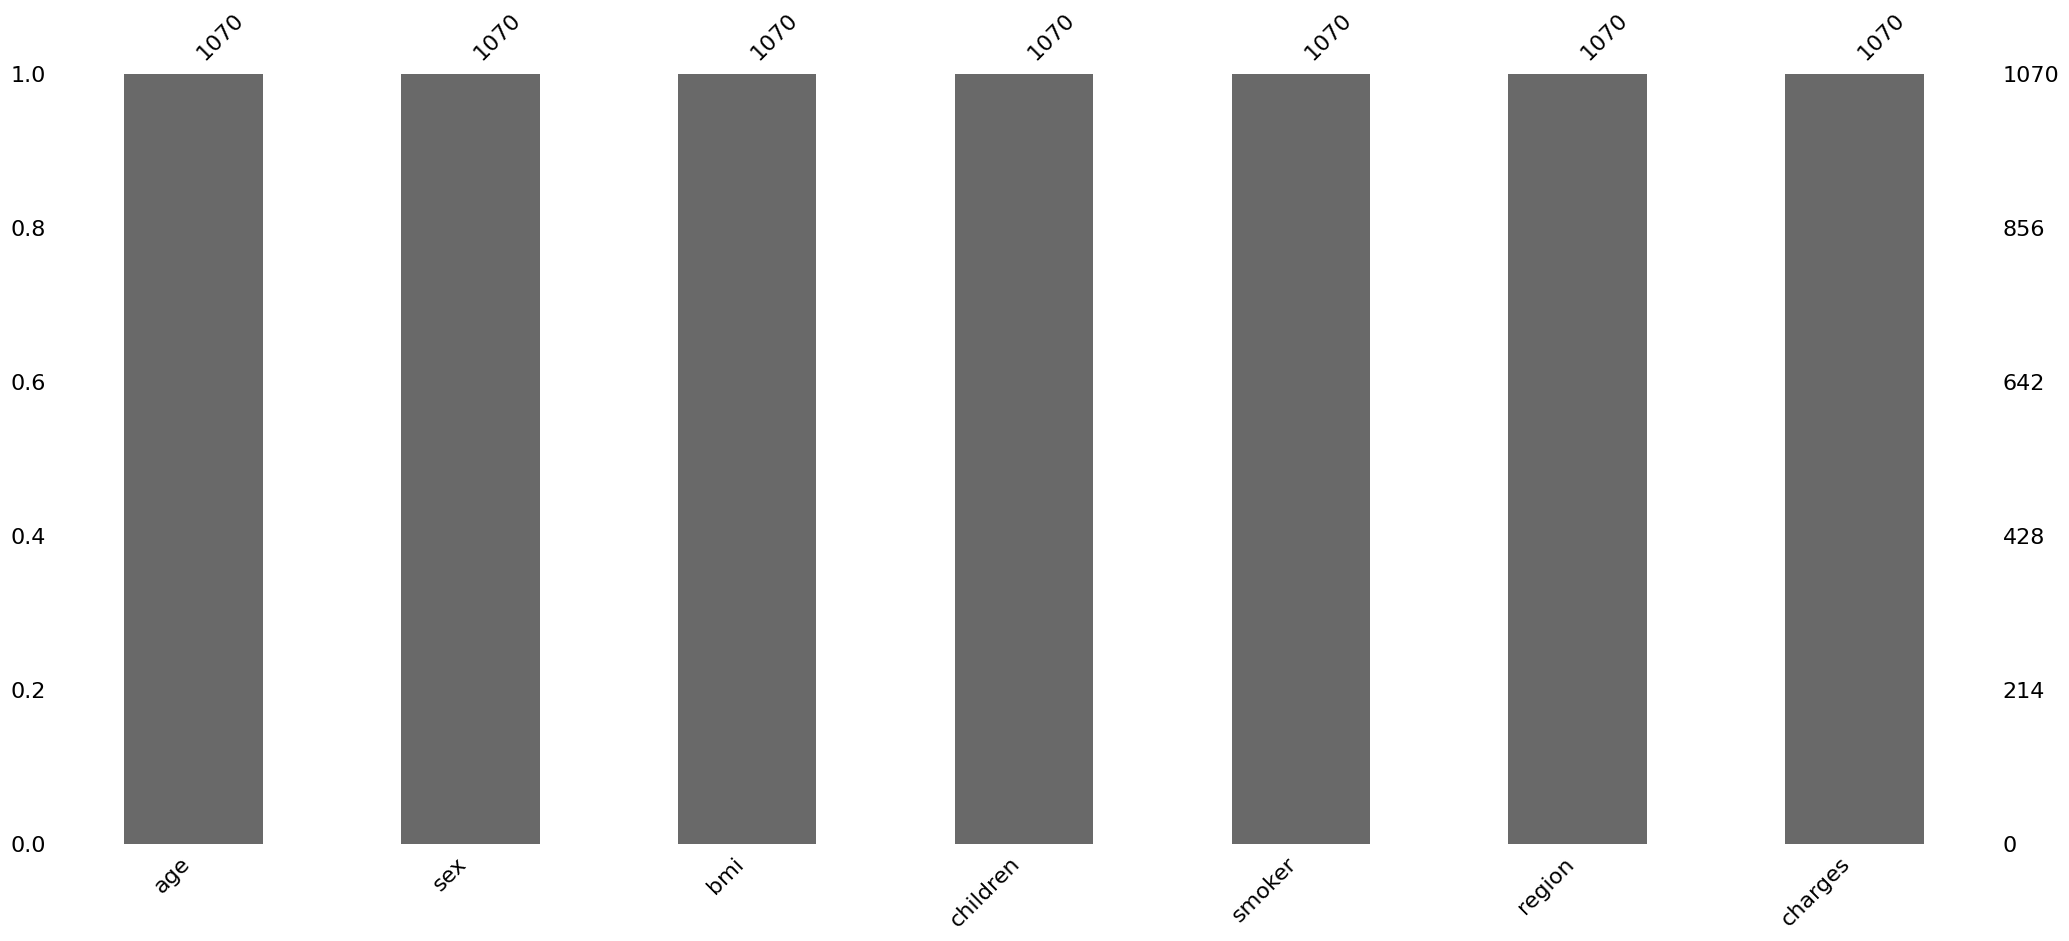

In [ ]:
msno.bar(train)
plt.show()

In [40]:
train.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [41]:
test.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 560 to 1126
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1070 non-null   int64  
 1   sex       1070 non-null   object 
 2   bmi       1070 non-null   float64
 3   children  1070 non-null   int64  
 4   smoker    1070 non-null   object 
 5   region    1070 non-null   object 
 6   charges   1070 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 66.9+ KB


**Correalation analysis**

To evaluate the initial predictive power and relationship between features, the Spearman Correlation method was employed. This non-parametric measure assesses the monotonic relationship between variables, which is more robust than Pearson correlation when dealing with non-normally distributed data or mixed-type features (ordinal/numerical).

Preprocessing for Correlation: To enable the calculation of the correlation matrix, categorical features were numerically encoded:

- Binary features (sex, smoker) were mapped to $0$ and $1$.
- The nominal categorical feature (region) was transformed using One-Hot Encoding to create dummy variables.

In [ ]:
df_processed = train.copy()

df_processed['sex'] = df_processed['sex'].map({'female': 0, 'male': 1})
df_processed['smoker'] = df_processed['smoker'].map({'no': 0, 'yes': 1})

df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)

spearman_correlation_matrix = df_processed.corr(method='spearman')

print("Spearman Correlation Matrix:")
spearman_correlation_matrix

Spearman Correlation Matrix:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
age,1.000000,-0.007514,0.115408,0.074915,-0.052136,0.509846,0.016374,-0.019407,0.025868
sex,-0.007514,1.000000,0.013138,0.015945,0.070908,0.010859,0.017047,-0.008217,-0.013911
bmi,0.115408,0.013138,1.000000,0.001815,-0.000910,0.126142,-0.103393,0.227545,0.016553
children,0.074915,0.015945,0.001815,1.000000,0.023610,0.133833,0.044798,-0.023379,-0.009604
smoker,-0.052136,0.070908,-0.000910,0.023610,1.000000,0.661788,-0.030547,0.051450,-0.033688
charges,0.509846,0.010859,0.126142,0.133833,0.661788,1.000000,-0.009979,0.013010,-0.041507
region_northwest,0.016374,0.017047,-0.103393,0.044798,-0.030547,-0.009979,1.000000,-0.336290,-0.320954
region_southeast,-0.019407,-0.008217,0.227545,-0.023379,0.051450,0.013010,-0.336290,1.000000,-0.343194
region_southwest,0.025868,-0.013911,0.016553,-0.009604,-0.033688,-0.041507,-0.320954,-0.343194,1.000000


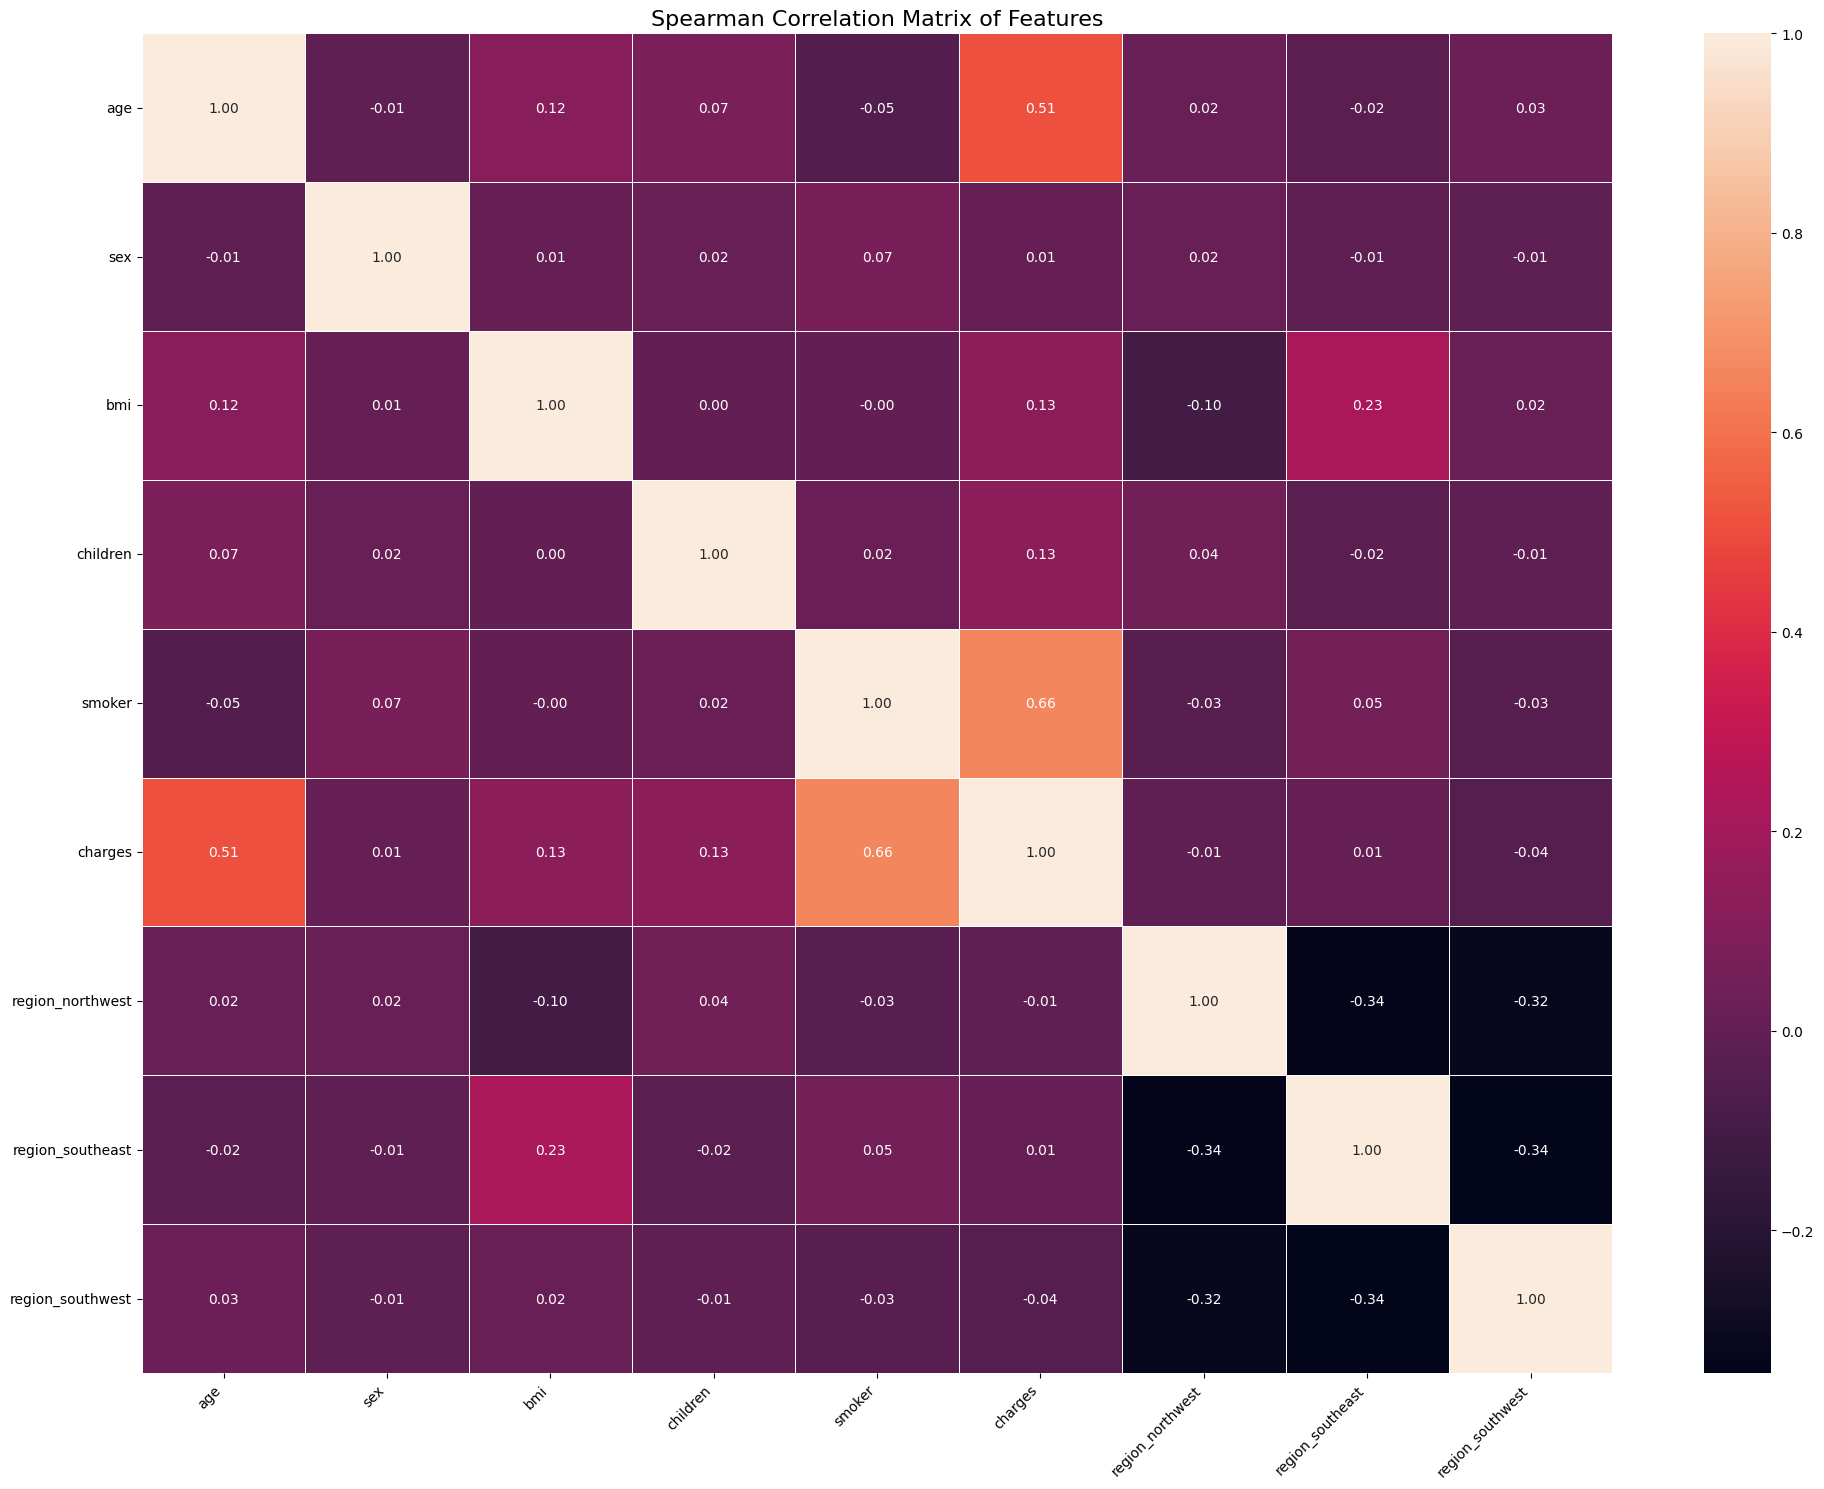

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(
    spearman_correlation_matrix,
    annot=True,
    cmap='rocket',
    fmt=".2f",
    linewidths=.5
)
plt.title('Spearman Correlation Matrix of Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation of Visualization Results (Spearman Correlation)**

The Spearman correlation heatmap visualization provided essential insights into feature significance:

- Smoker Dominance: The smoker feature demonstrated the strongest correlation with charges ($+0.66$), indicating it is the most influential predictor.
- Age Significance: age showed the second strongest relationship ($+0.51$).
- Minor Influences: bmi ($+0.13$) and children ($+0.13$) exhibited only weak to moderate correlations.
- Negligible Features: sex and the region dummy variables showed negligible correlation, suggesting minimal linear or monotonic predictive power for the target variable.

This analysis established that the model's performance will be heavily dependent on smoker and age.

**Target Labels Distribution**

The final step in the exploratory analysis involved examining the distribution of the charges target variable. Analyzing the distribution of the target variable is critical. Highly skewed or multi-modal distributions can violate the assumptions of some modeling techniques and often necessitate transformation (e.g., log-transformation) before training to improve model stability and convergence.


--- Distribution Plot of Charges ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


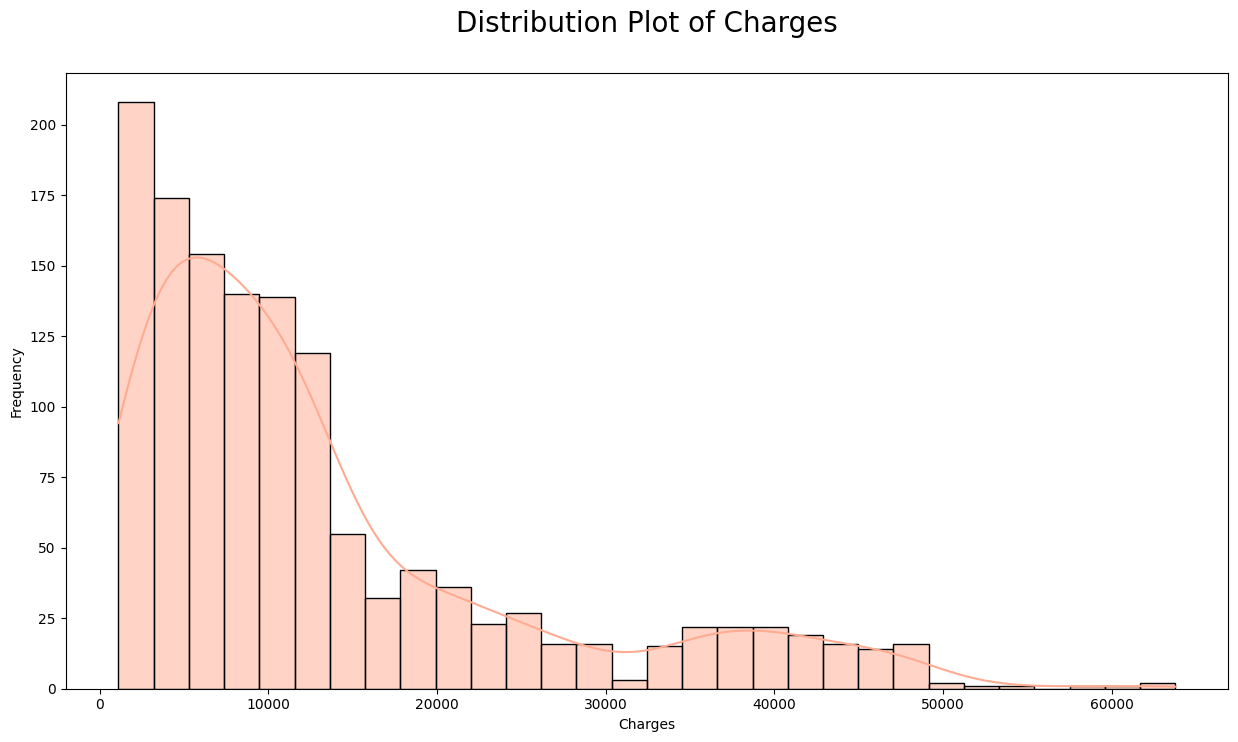

In [ ]:
print("\n--- Distribution Plot of Charges ---")
plt.figure(figsize = (15, 8))
sns.histplot(df['charges'], kde=True, color='#FFAB91') 
plt.title('Distribution Plot of Charges\n', fontsize = 20)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()


--- Distribution Plot of Charges (Seaborn) ---


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

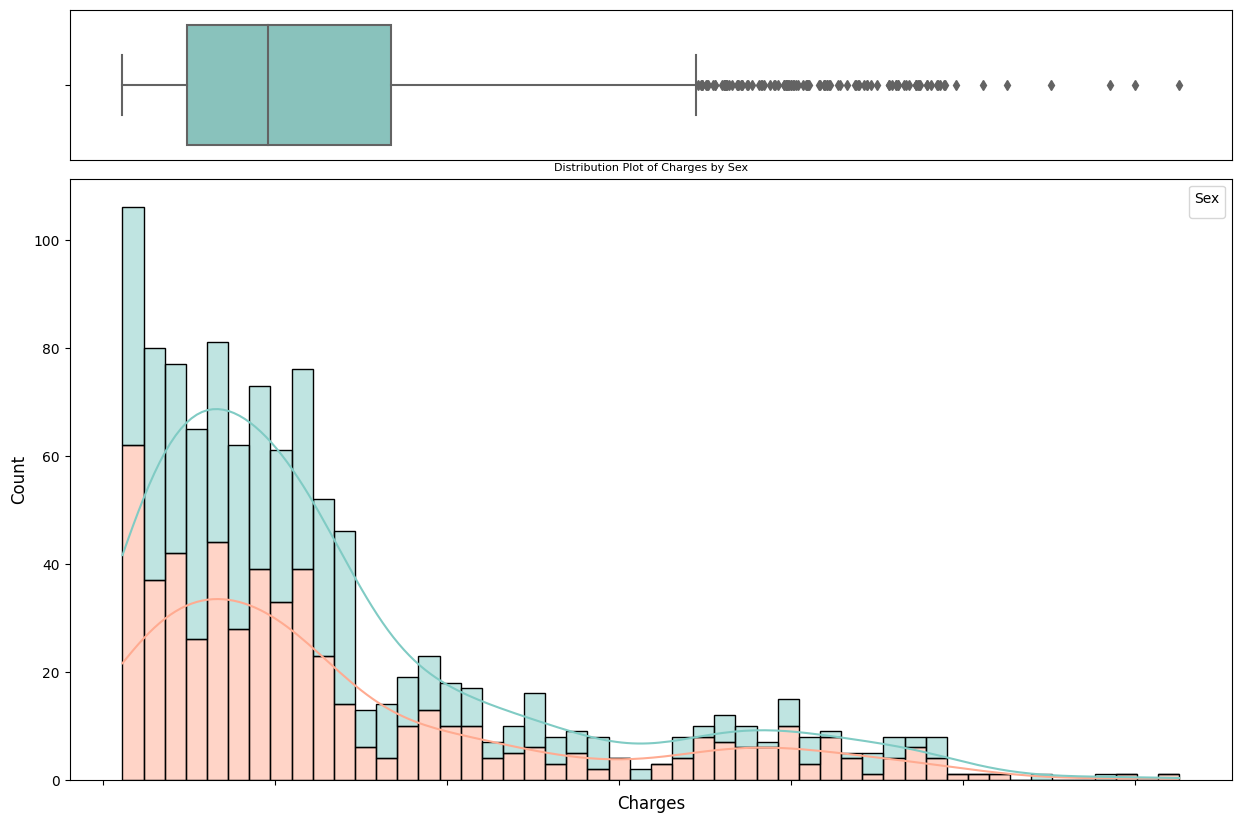

In [ ]:
print("\n--- Distribution Plot of Charges (Seaborn) ---")

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8], hspace=0.05)

ax_box = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[1, 0], sharex=ax_box)

custom_palette = ["#80CBC4", "#FFAB91"]

sns.boxplot(data=train, x='charges', hue='sex', ax=ax_box, palette=custom_palette)
ax_box.set(xlabel='', xticklabels=[])
ax_box.tick_params(axis='x', bottom=False)

sns.histplot(data=train, x='charges', hue='sex', multiple='stack', kde=True, bins=50, ax=ax_hist, palette=custom_palette)
ax_hist.set_title('Distribution Plot of Charges by Sex', fontsize=8)
ax_hist.set_xlabel('Charges', fontsize=12)
ax_hist.set_ylabel('Count', fontsize=12)
ax_hist.legend(title='Sex')

plt.tight_layout()
plt.show()

**Interpretation of Visualization Results (Distribution Plots)**

The distribution plots of charges revealed key structural characteristics:

- Overall Skew: The primary histogram showed that the charges distribution is highly right-skewed with a long tail extending toward higher values. The bulk of the charges are concentrated below $\$15,000$. This strong skew confirms that the variable's variance is unevenly distributed and requires special handling (like scaling and possibly log-transformation) during preprocessing.
- Multi-Modal Structure: The distribution is not unimodal; rather, it exhibits three distinct peaks or clusters (modality). This is a strong indicator that the dataset is composed of several underlying groups, likely driven by a key categorical variable.
- Sex Comparison: When the distribution is split and visualized by sex, the histograms for both groups retain the overall skewed and multi-modal structure. The corresponding box plots show that the central tendency (median) and the spread of charges are very similar between the two groups, confirming the finding from the correlation matrix that sex is not a strong differentiator of the charges. The multi-modal nature, therefore, must be driven by another, more powerful categorical feature, strongly suggested by the correlation analysis to be smoker.

These findings suggest that a model attempting to predict charges must account for the non-linear, multi-modal nature of the target, which directly informs the choice of a more complex architecture than a simple linear Perceptron.

# Features Engineering

This phase prepares the raw input data for the Perceptron model by performing targeted feature engineering, mandatory scaling, and dimensionality reduction, ensuring the data is in the optimal numerical format for gradient-based learning.

**Features Selection**

Based on the preceding correlation analysis, features with negligible predictive power—specifically sex and region—were dropped from both the training and testing datasets. This feature selection step simplifies the model and reduces noise, which can be critical for the performance of a simple linear model like the Perceptron. The remaining features are age, bmi, children, and the categorical variable smoker.

In [16]:
train = train.drop(columns=['sex', 'region'], errors='ignore')
test = test.drop(columns=['sex', 'region'], errors='ignore')
train.head()

,age,bmi,children,smoker,charges
560,46,19.95,2,no,9193.83850
1285,47,24.32,0,no,8534.67180
1142,52,24.86,0,no,27117.99378
969,39,34.32,5,no,8596.82780
486,54,21.47,3,no,12475.35130


**Encoding Categorical Features**

The binary categorical feature smoker (yes/no) was converted into a numerical format using One-Hot Encoding.  This process transforms the single categorical column into two binary columns, `smoker_yes and smoker_no`. One-Hot Encoding is preferred for nominal (non-ordered) categorical data as it prevents the model from incorrectly inferring an ordinal relationship (e.g., that 'yes' is numerically greater than 'no' in an arbitrary mapping like 1 and 0).

**Data Normalization (Standardization)**

`StandardScaler`: Neural networks, including the Perceptron, are highly sensitive to the scale of input features because they rely on Gradient Descent for optimization. Features with large ranges can dominate the loss function, causing weights to oscillate or training to diverge. Standardization (or Z-score normalization) transforms the data such that it has a mean of $0$ and a standard deviation of $1$. This ensures that all features contribute equally to the distance calculations and stabilizes the training process.

The `StandardScaler` was fitted exclusively on the training data's numerical columns (age, bmi, children) and the target column (charges). The resulting transformation parameters (mean and standard deviation) were then applied to transform both the training and testing sets. Crucially, the target variable (charges) was also scaled, which helps minimize the magnitude of the loss and improves the stability of the gradients during backpropagation.

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(train[['smoker']])

smoker_encoded_train = encoder.transform(train[['smoker']])
smoker_df_train = pd.DataFrame(smoker_encoded_train, columns=encoder.get_feature_names_out(['smoker']), index=train.index)

smoker_encoded_test = encoder.transform(test[['smoker']])
smoker_df_test = pd.DataFrame(smoker_encoded_test, columns=encoder.get_feature_names_out(['smoker']), index=test.index)

train = train.drop('smoker', axis=1)
train = pd.concat([train, smoker_df_train], axis=1)

test = test.drop('smoker', axis=1)
test = pd.concat([test, smoker_df_test], axis=1)

numerical_cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

scaler.fit(train[numerical_cols])

y_scaler = StandardScaler()
y_scaler.fit(train[['charges']])
train['charges'] = y_scaler.transform(train[['charges']])
test['charges'] = y_scaler.transform(test[['charges']])
train[numerical_cols] = scaler.transform(train[numerical_cols])
test[numerical_cols] = scaler.transform(test[numerical_cols])
train

,age,bmi,children,charges,smoker_no,smoker_yes
560,0.472227,-1.756525,0.734336,-0.345621,1.0,0.0
1285,0.543313,-1.033082,-0.911192,-0.400488,1.0,0.0
1142,0.898745,-0.943687,-0.911192,1.146332,1.0,0.0
969,-0.025379,0.622393,3.202629,-0.395314,1.0,0.0
486,1.040918,-1.504893,1.557100,-0.072478,1.0,0.0
...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,-0.731229,1.0,0.0
1130,-0.025379,-1.107579,3.202629,-0.396523,1.0,0.0
1294,1.325264,-0.891539,-0.911192,-0.117777,1.0,0.0
860,-0.167551,2.820864,0.734336,2.727461,0.0,1.0


**Features and Target Labels Split**

In [ ]:
x_train = train.drop('charges', axis=1) 
y_train = train['charges'] 
x_test = test.drop('charges', axis=1) 
y_test = test['charges'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 5)
y_train shape: (1070,)
X_test shape: (268, 5)
y_test shape: (268,)


**Dimensionality Reduction (PCA)**

**Principal Component Analysis (PCA)**: PCA is an unsupervised dimensionality reduction technique that linearly transforms the original feature space into a new, lower-dimensional space composed of Principal Components (PCs). These PCs are orthogonal (uncorrelated) and capture the maximum amount of variance in the data.

In this project, PCA was applied to reduce the processed feature set (now 5 dimensions: age, bmi, children, smoker_yes, smoker_no) down to two principal components ($n=2$). This reduction serves two primary goals:

- **Noise Reduction**: By focusing on components that explain the most variance, potential noise in less informative original features is minimized.
- **Visualization**: Reducing the feature space to two dimensions creates a plane that allows the entire dataset to be plotted and visualized, which is essential for diagnosing the Perceptron's performance in the next steps.

In [19]:
pca = PCA(n_components=2)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

**Dimensionality Reduction Visualization**

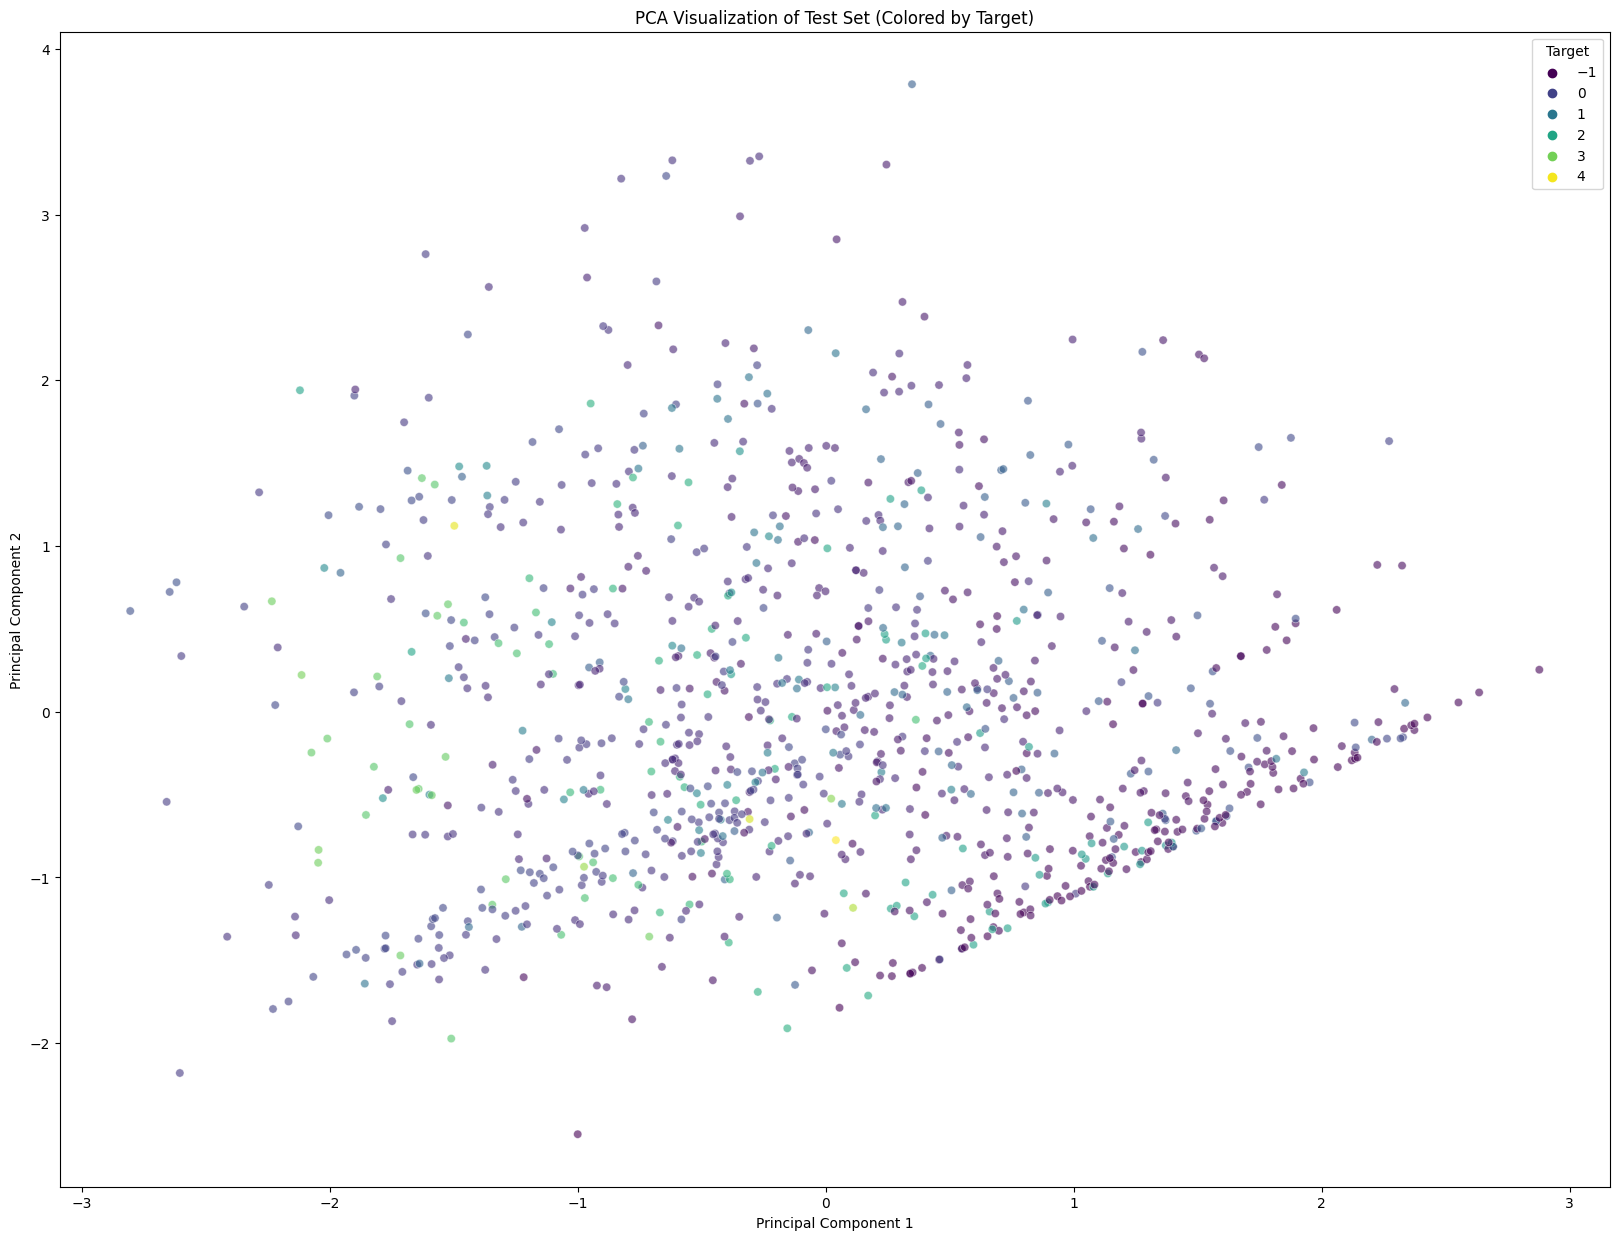

In [ ]:
plot_data = pd.DataFrame({
    'PC1': x_train[:, 0],
    'PC2': x_train[:, 1],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Test Set (Colored by Target)")

plt.show()

**Interpretation of Visualization Results (PCA Scatter Plot)**

The scatter plot visualizes the entire training dataset projected onto the two principal components (PC1 and PC2), with points colored according to the scaled target value (charges).

- Cluster Separation: The plot clearly reveals two major clusters of data points along the PC1 axis, confirming the structure previously hinted at by the multi-modal distribution of charges.
- PC1 Driving Variance: The primary separation and variance in the data occur along PC1. This component is clearly highly correlated with the target variable, as one cluster on the far right (high PC1 values) is predominantly colored in bright yellow, indicating high charges. The other, larger cluster on the left (low PC1 values) is colored in deep blue, representing low charges.
- Feature Interpretation: Given that smoker was identified as the strongest predictor (correlation $\approx +0.66$), the separation along PC1 strongly suggests that this component is dominated by the smoker feature. The high PC1 cluster likely represents smokers, and the low PC1 cluster represents non-smokers.
- Non-Linearity in Low-Charge Cluster: The large, low-charge cluster exhibits significant internal spread and structure across both PC1 and PC2, where the colors (charges) transition subtly from deep blue to light blue. This variance indicates that for non-smokers, predicting charges requires capturing more complex, secondary relationships involving age, bmi, and children, which are not linearly separable by a simple hyperplane.

The visualization confirms that the relationship between features and charges is highly non-linear and piecewise linear (two distinct groups). This non-linear structure reinforces the expectation that a single, strictly linear Perceptron will perform poorly, as it can only model a single flat plane to separate these complex, clustered data points.

# Model Training

## Model Architecture, Model Building, and Model Training (Keras)

**Building a Keras Perceptron for Regression**

A Perceptron represents the most fundamental unit of a neural network—a single artificial neuron. When used for regression, it computes a linear relationship between the input features and the continuous target variable. In Keras, this is accomplished using a single, Dense layer without an activation function, which defaults to a linear activation.The model construction typically involves the following steps:

- Sequential Model Initialization: The keras.Sequential API is used to create a model structure where layers are stacked linearly.
- Dense Layer (The Perceptron): A single layers.Dense layer is added. For a regression task predicting a single value (like house price or insurance charge), the units parameter is set to 1. Crucially, the activation function is either explicitly set to linear or left unspecified (the default for a Dense layer in Keras is linear activation when no activation is provided), ensuring the output is a continuous, unconstrained value suitable for regression.
- Model Compilation: The model is configured for training using the `model.compile()` method. This step specifies the optimization algorithm, the loss function, and the metrics.
- Model Training: The `model.fit()` method executes the training process, iteratively adjusting the model's weights and bias to minimize the loss function on the training data.

**Essential Hyperparameters**

Hyperparameters are external configuration settings whose values cannot be estimated from the data. They are chosen before training begins and directly govern the learning process and model structure. For a Perceptron regression model, the most critical hyperparameters fall into three categories:

**1. Model Structure**

- Units (in Dense layer): This defines the number of neurons in the layer. For single-output regression, this is almost always set to 1, meaning the perceptron calculates a single output value ($\hat{y}$) from the inputs.

**2. Optimization Parameters (in compile)**

This algorithm determines how the model's weights and biases are modified during backpropagation to reduce the loss. Algorithms like Adam or Stochastic Gradient Descent (SGD) are commonly used. Adam is often preferred as it adapts the learning rate for each parameter, providing efficient convergence.
- Learning Rate (of the Optimizer): This scaling factor determines the step size taken during each iteration of the weight update. A high learning rate can lead to unstable training and overshooting the optimal solution. A very low rate results in slow training. It must be carefully tuned, often to a small value like $0.001$.
- Loss Function: This function quantifies the error between the model's predictions and the true target values. For regression, the standard choice is Mean Squared Error (MSE). MSE calculates the average of the squared differences, heavily penalizing large errors.

**3. Training Control Parameters (in fit and Callbacks)**

- Epochs: This represents the number of full passes the training algorithm makes over the entire training dataset. Training continues for this many cycles unless stopped early. The ideal number is found empirically, often set high (e.g., 100) and combined with Early Stopping.
- Batch Size: This is the number of data samples processed before the model's parameters (weights and biases) are updated. Smaller batch sizes introduce more noise into the weight updates, potentially helping the model escape local minima, but also increasing training time. Larger batch sizes provide a smoother, faster convergence path but require more memory.
- Patience (for Early Stopping): This is the number of epochs with no improvement on the monitored metric (typically validation loss) after which training is halted. This mechanism prevents overfitting by ensuring the model stops training once its generalization ability on unseen data begins to decline, thereby saving the weights from the best-performing epoch.

**Perceptron Modeling and Training Concepts**

This stage focuses on building and training a basic Perceptron model for regression, using the preprocessed and dimensionally reduced data, and monitoring its performance using standard metrics.

**Model Architecture and Compilation**

Perceptron : The Perceptron, in its simplest form, is a linear model used for classification. When adapted for regression, it takes the form of a single-layer neural network with one output neuron and a linear activation function. This architecture calculates a weighted sum of inputs and biases (a linear equation) to produce a continuous output. The model in this analysis has an input shape of 2 (corresponding to the two PCA components, PC1 and PC2) and one output neuron for predicting the scaled charge value. This results in only three trainable parameters (two weights for the inputs and one bias term). 

**Loss Function and Optimization:**

- Loss: The model uses Mean Squared Error (MSE) as its loss function. MSE calculates the average squared difference between the predicted and actual scaled charge values. For regression tasks, MSE is highly effective because it heavily penalizes larger errors, encouraging the model to find a solution that minimizes these significant outliers.
- Optimizer: The Adam optimizer was chosen. Adam is a powerful and efficient extension of the classic Stochastic Gradient Descent algorithm. It adaptively adjusts the learning rate for each weight based on the average of past gradients and squared gradients, leading to faster and more stable convergence, especially in the early stages of training.
- Early Stopping : To prevent the model from overfitting (learning the training data too well, losing generalization capability), an Early Stopping callback was implemented. This technique monitors the validation loss and stops training if the loss fails to improve for a set number of epochs (`patience = 8`). The model weights from the epoch with the best validation performance are automatically restored, ensuring the final model is the most generalized version.

In [ ]:
input_dim = x_train.shape[1]

model = keras.Sequential([
    layers.Dense(1, input_shape=(input_dim,), name='output_layer')
])

print("\n--- Model Architecture (Perceptron) ---")
model.summary()
total_params = model.count_params()
print(f"Number of trainable parameters: {total_params}")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mean_absolute_error', 'mean_squared_error'])

early_stopping_patience = 8
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=early_stopping_patience,
    restore_best_weights=True,
    verbose=1
)

epochs = 100 
print("\n--- Training Model ---")

history = model.fit(
    x_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stopping_callback],
    verbose=1
)

print("\nTraining complete.")


--- Model Architecture (Perceptron) ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-19 17:10:11.847478: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output_layer (Dense)            │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Number of trainable parameters: 3

--- Training Model ---
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.3443 - mean_absolute_error: 0.9285 - mean_squared_error: 1.3443 - val_loss: 1.1646 - val_mean_absolute_error: 0.8486 - val_mean_squared_error: 1.1646
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2189 - mean_absolute_error: 0.8793 - mean_squared_error: 1.2189 - val_loss: 1.1283 - val_mean_absolute_error: 0.8326 - val_mean_squared_error: 1.1283
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2497 - mean_absolute_error: 0.8936 - mean_squared_error: 1.2497 - val_loss: 1.0962 - val_mean_absolute_error: 0.8182 - val_mean_squared_error: 1.0962
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2247 - mean_absolute_error: 0.8868 - mean_squared_error: 1.2247 - val_loss: 1.0673 - val_mean_absolute_error: 0.8036 - val_mean_squared_error: 1.0673
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1690 - mean_absolute_error: 0.8707 -

**Training History (Keras)**


Training complete.


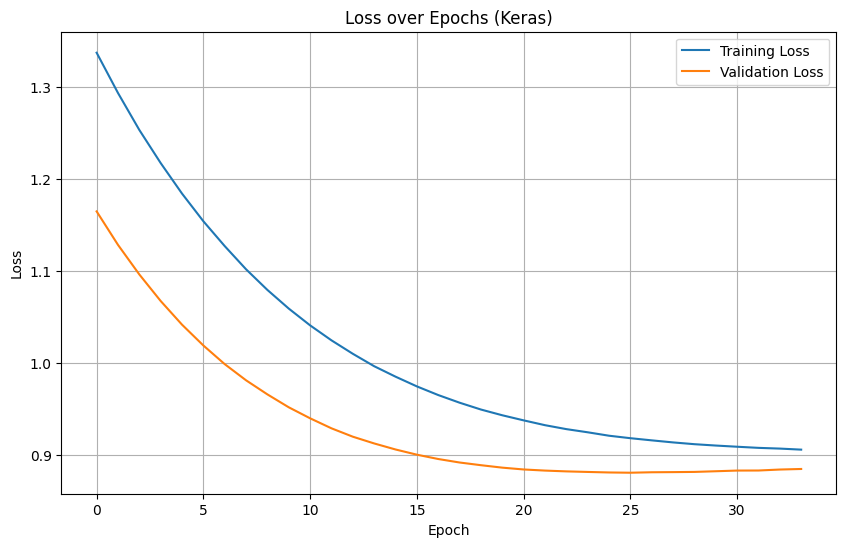

In [ ]:
print("\nTraining complete.")

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (Keras)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The plot tracking the training and validation loss across epochs reveals the learning dynamics of the Perceptron:

- Convergence: Both the training loss and the validation loss decreased rapidly in the initial epochs, indicating successful learning and adjustment of weights by the Adam optimizer.
- Plateau and Stopping: After approximately 20 epochs, both loss curves flattened considerably, reaching a plateau.
- Early Stop Trigger: Training was halted early at Epoch 34 due to the early stopping mechanism. The validation loss stabilized and failed to show significant improvement for eight consecutive epochs, signifying that the model had reached its best possible performance given its linear structure. The lowest validation loss achieved was approximately $0.88$.

The rapid convergence to a relatively high final loss value suggests that the simple linear architecture has reached its limitations in modeling the non-linear structure of the insurance data.

**Regression Hypersurfaces Visualization 2D (Keras)**


--- Visualizing Regression Prediction Surface ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


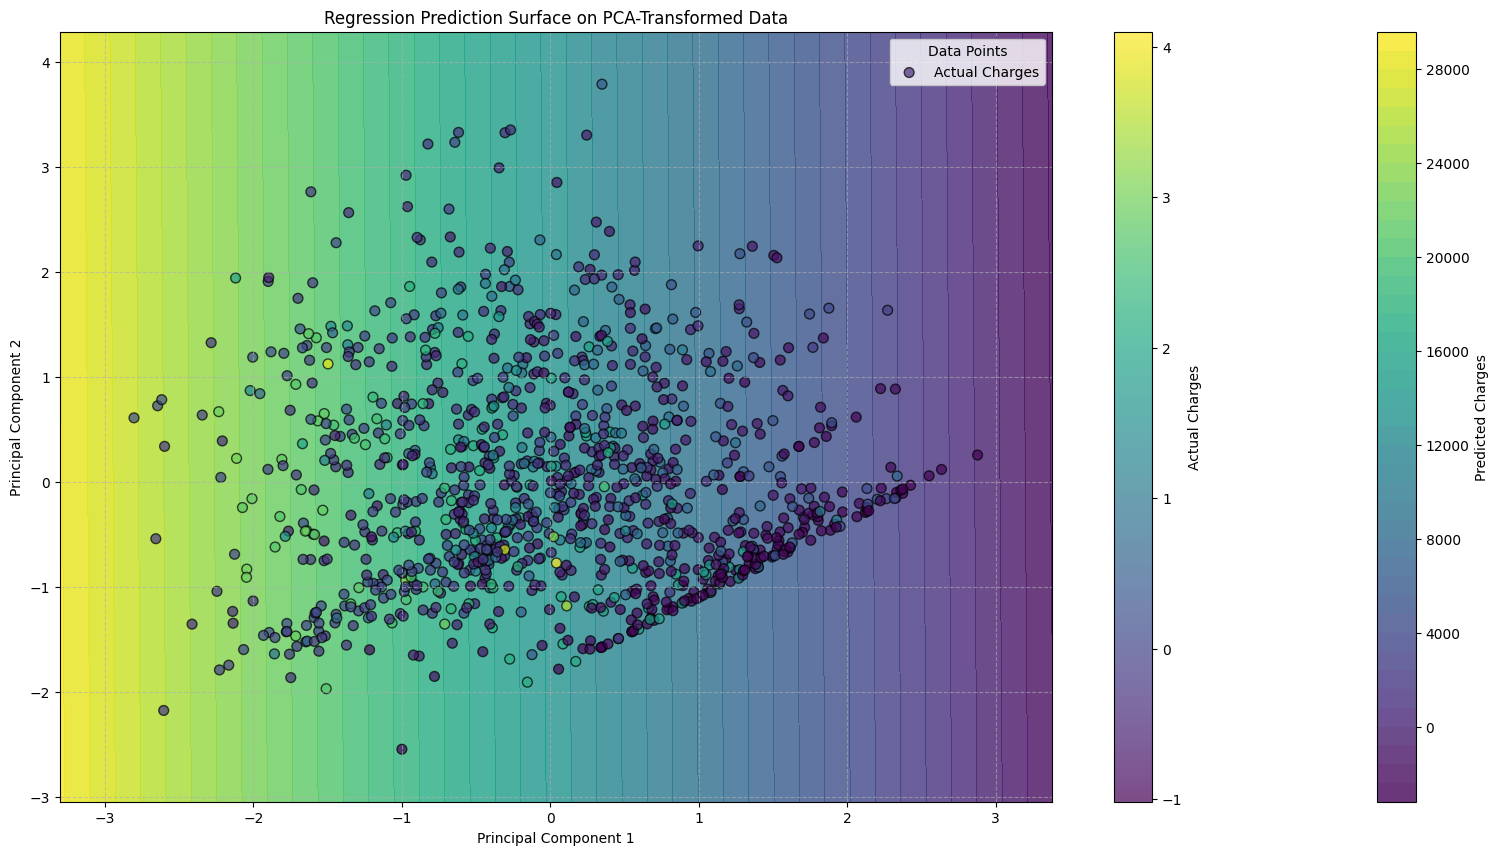

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted_original = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).flatten()
Z_predicted = Z_predicted_original.reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Hypersurfaces Visualization 3D (Keras)**


--- Visualizing Regression Prediction Surface (3D) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


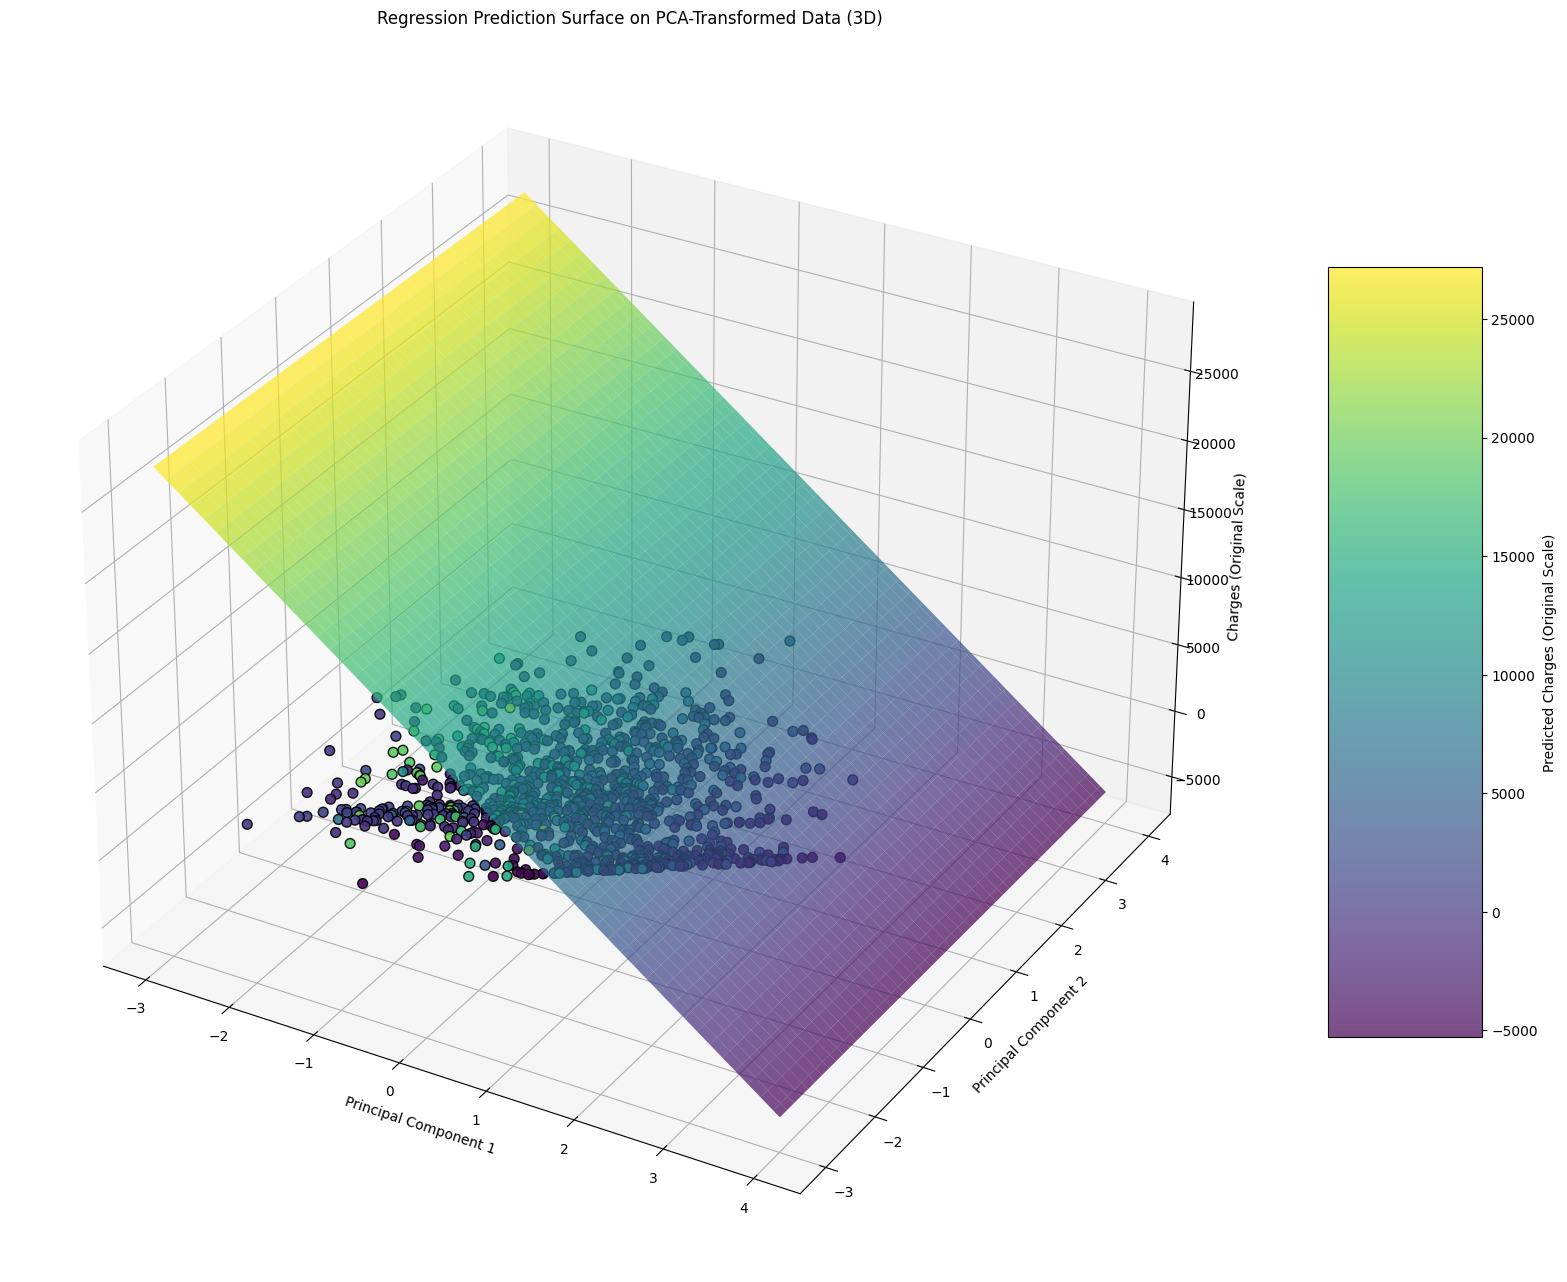

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0
y_min, y_max = -3.0, 4.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_train[:, 0], x_train[:, 1], y_train, c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D)")
plt.show()

**Interpretation of Visualization Results (Regression Hypersurface)**

The visualizations of the regression prediction surface, both 2D and 3D, are crucial for understanding the model's limitations in the context of the data's inherent complexity:

- Linear Plane (3D View): The 3D plot shows the model's prediction as a single, flat hyperplane cutting through the 2D PCA space (PC1 vs. PC2) to predict the charge values on the Z-axis.
- Misalignment with Data Clusters: The model's fundamental limitation is apparent here. The insurance data is clearly clustered into two distinct groups: a large low-charge cluster (non-smokers, predominantly dark blue) and a separate high-charge cluster (smokers, predominantly yellow). The single linear plane attempts to average the two clusters, resulting in gross underestimation for many high-charge points and overestimation for many low-charge points.
- 2D Prediction Map: The 2D contour plot reinforces this issue. The predictions (colored background) show a smooth, linear gradient across the PCA space. This linear gradient cannot effectively capture the sharp, non-linear jump in charges that occurs between the non-smoker (low PC1) cluster and the smoker (high PC1) cluster. The boundary between the two clusters is complex, but the linear model can only offer a single, continuous transition, leading to high prediction error where the clusters are separated.

In conclusion, the Perceptron model successfully minimized the loss for its linear capability but failed to accurately model the data because the relationship between the features and the target is piecewise linear and non-linear, confirming the need for a more complex, multi-layered neural network architecture to capture the distinct clusters in the data.

## Model Architecture, Model Building, and Model Training (TensorFlow custom functions)

**Building a TensorFlow Perceptron for Regression**

A Perceptron serves as the simplest form of a neural network, consisting of a single neuron. For regression tasks, this neuron calculates a linear function of its inputs to produce a continuous output ($\hat{y}$), such as a price or score. In TensorFlow, the Keras API is the standard way to implement this, primarily through a Dense layer with a linear activation function.

**Perceptron Implementation Steps**

- Model Definition: The structure begins with defining the model architecture. The tf.keras.Sequential model is the easiest way to stack layers. The Perceptron is represented by a single `tf.keras.layers.Dense layer`.
    - The units parameter is set to 1 because the model predicts a single output value.
    - The activation function is either explicitly set to 'linear' or omitted, as the Dense layer defaults to a linear activation. This ensures the output is unrestricted and continuous, which is necessary for regression.
- Model Compilation: The `model.compile()` method prepares the model for the training process. This is where the learning rules are defined, including the choice of optimizer, loss function, and evaluation metrics.
- Training: The `model.fit()` method initiates the optimization process. During training, the model repeatedly calculates the error (loss) and uses the chosen optimizer (via backpropagation) to adjust the layer's internal weights and bias in an effort to minimize the loss.

**Essential Hyperparameters and Their Meaning**

Hyperparameters are high-level configuration parameters that are set before the training process begins, dictating the model's structure and learning strategy.

**1. Model Structure Hyperparameter**

- Units (in Dense layer): This determines the number of output dimensions for the layer. For most single-variable regression problems, this value is fixed at 1. This means the Perceptron has one weight for each input feature plus a single bias term, and it calculates only one output value $\hat{y}$. 

**2. Optimization Hyperparameters (in compile)**

- Optimizer: This is the algorithm responsible for modifying the model's weights and bias to reduce the loss function value. Common optimizers like Adam or `RMSprop` dynamically adjust the update rate for each parameter, often leading to faster and more robust convergence than basic Gradient Descent. The choice of optimizer significantly affects training speed and the final model quality.
- Learning Rate: This scalar value controls the magnitude of the step taken by the optimizer when updating parameters. A carefully selected learning rate (typically small, such as $0.001$) is crucial. Too high, and the model may overshoot the minimum loss. Too low, and training becomes excessively slow.
- Loss Function: This mathematical function calculates the penalty for the model's errors. The optimizer's goal is to minimize this value. For regression, the Mean Squared Error (MSE) is the most common choice. It calculates the average of the squared differences between the predicted values ($\hat{y}$) and the true values ($y$). Squaring the errors means larger mistakes are penalized much more heavily than smaller ones.

**3. Training Control Hyperparameters (in fit and Callbacks)**

- Epochs: One epoch signifies a complete pass of the entire training dataset through the model. This parameter determines the total number of learning cycles. The final value is typically determined by the convergence of the validation loss, often managed automatically by an Early Stopping mechanism.
- Batch Size: This is the number of data samples processed in a single forward/backward pass before the model's parameters are updated. A larger batch size provides a more accurate estimate of the gradient but requires more memory and can get stuck in sharp local minima. A smaller batch size introduces more noise, which can help the model generalize better but makes training slower.
- Patience (for Early Stopping): This is a crucial regularization parameter specifying the number of epochs to wait for an improvement in the monitored validation metric (like validation loss) before stopping training. It prevents the model from overfitting to the training data. If the model's performance on the unseen validation set stops improving for the duration of the patience window, training is terminated, and the model weights from the best-performing epoch are restored.

**Custom Keras Perceptron Modeling and Training Concepts**

This section demonstrates the creation and training of a Perceptron model for regression using custom Keras components for the layer, loss function, and metrics. This approach provides a deeper understanding of the fundamental computational operations within a neural network framework.

**Custom Component Implementation**

- Custom Perceptron Layer (`CustomPerceptron`): The model's core is a manually defined layer, which represents a single neuron. This neuron is configured for regression, meaning it performs a linear transformation of the input data.
    - build Method: This method initializes the trainable parameters: the weights (`self.w`) and the bias (`self.b`). The weights are randomly initialized, and the bias is initialized to zero, following standard neural network practice. The number of weights is equal to the input dimension (2 PCA components), plus one bias, resulting in three total parameters.
    - call Method: This method defines the forward pass computation, which is the heart of the Perceptron: the matrix multiplication of the input tensor (inputs) with the weights (`self.w`), followed by the addition of the bias (`self.b`). This operation implements the core linear function $\hat{y} = \mathbf{x} \cdot \mathbf{w} + b$.

- Custom Loss and Metrics: The analysis utilizes custom functions (`custom_mse_loss, custom_mae, custom_mse`) defined using TensorFlow operations.

    - Loss: Mean Squared Error (MSE) is implemented using `tf.reduce_mean(tf.square(y_true - y_pred))`. MSE is the standard objective function for regression, penalizing larger errors exponentially more than smaller ones.
    - Metrics: Mean Absolute Error (MAE) and MSE are calculated to provide interpretable measures of model performance during training.

**Training Dynamics and Early Stopping**

The model is compiled using the Adam optimizer with a low learning rate (`0.001`) to ensure stable convergence. An Early Stopping callback is again utilized, monitoring the val_loss (validation MSE) with a patience of 8 epochs. This process is essential to halt training once the model's performance on unseen data plateaus, mitigating the risk of overfitting.

In [ ]:
def custom_mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def custom_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def custom_mse(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

class CustomPerceptron(layers.Layer):
    def __init__(self, units=1, **kwargs):
        super(CustomPerceptron, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(
            name='kernel',
            shape=(input_shape[-1], self.units),
            initializer='random_normal',
            trainable=True
        )
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super(CustomPerceptron, self).build(input_shape)

    def call(self, inputs):
        return tf.matmul(inputs, self.w) + self.b

    def get_config(self):
        config = super(CustomPerceptron, self).get_config()
        config.update({"units": self.units})
        return config

input_dim = x_train.shape[1]

model = keras.Sequential([
    CustomPerceptron(units=1, input_shape=(input_dim,), name='custom_perceptron_output')
])

print("\n--- Model Architecture (Perceptron with Custom Layer) ---")
model.summary()
total_params = model.count_params()
print(f"Number of trainable parameters: {total_params}")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=custom_mse_loss,
              metrics=[custom_mae, custom_mse])

early_stopping_patience = 8
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=early_stopping_patience,
    restore_best_weights=True,
    verbose=1
)

epochs = 100 
print("\n--- Training Model ---")

history = model.fit(
    x_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stopping_callback],
    verbose=1
)

print("\nTraining complete.")


--- Model Architecture (Perceptron with Custom Layer) ---


/tmp/ipykernel_38/2489917608.py:31: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super(CustomPerceptron, self).__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_perceptron_output        │ (None, 1)              │             3 │
│ (CustomPerceptron)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Number of trainable parameters: 3

--- Training Model ---
Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - custom_mae: 0.7267 - custom_mse: 0.9708 - loss: 0.9707 - val_custom_mae: 0.7693 - val_custom_mse: 1.0592 - val_loss: 1.0623
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7274 - custom_mse: 0.9879 - loss: 0.9882 - val_custom_mae: 0.7651 - val_custom_mse: 1.0381 - val_loss: 1.0413
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7508 - custom_mse: 1.0353 - loss: 1.0353 - val_custom_mae: 0.7614 - val_custom_mse: 1.0202 - val_loss: 1.0238
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7053 - custom_mse: 0.8522 - loss: 0.8521 - val_custom_mae: 0.7581 - val_custom_mse: 1.0053 - val_loss: 1.0092
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - custom_mae: 0.7131 - custom_mse: 0.8927 - loss: 0.8927 - val_custom_mae: 0.7558 - val_custom_mse: 0.9899 - val_loss: 0.9941
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - cus

**Training History (TensorFlow custom functions)**

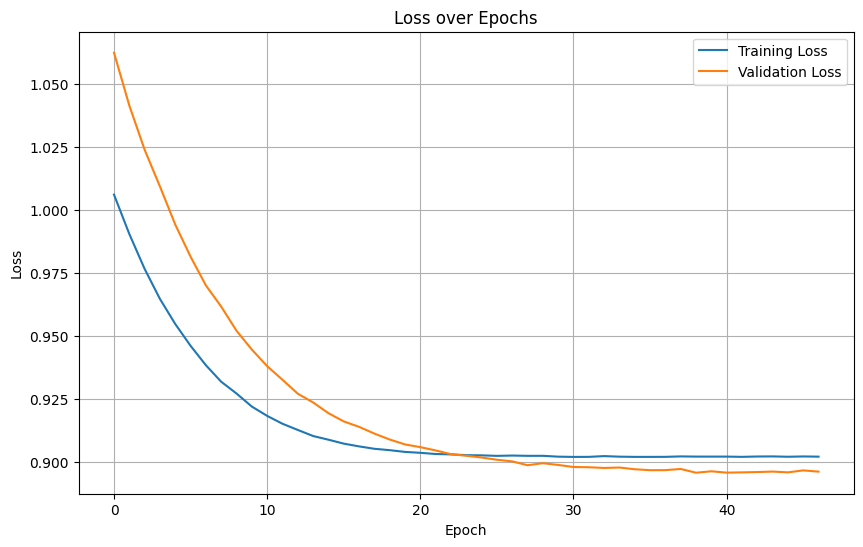

In [26]:
# --- Plotting Training History (Loss) ---
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The training history reveals that the model achieved its best performance (lowest validation loss) at Epoch 39. After this point, the validation loss began to show minor fluctuations but no significant improvement. Consequently, the early stopping mechanism triggered, ending the training at Epoch 47 and restoring the optimal weights from Epoch 39. The overall training process mirrors the behavior of the previous, non-custom implementation, which is expected since the underlying mathematical architecture is identical.

**Regression Hypersurfaces Visualization 2D (TensorFlow custom functions)**


--- Visualizing Regression Prediction Surface ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


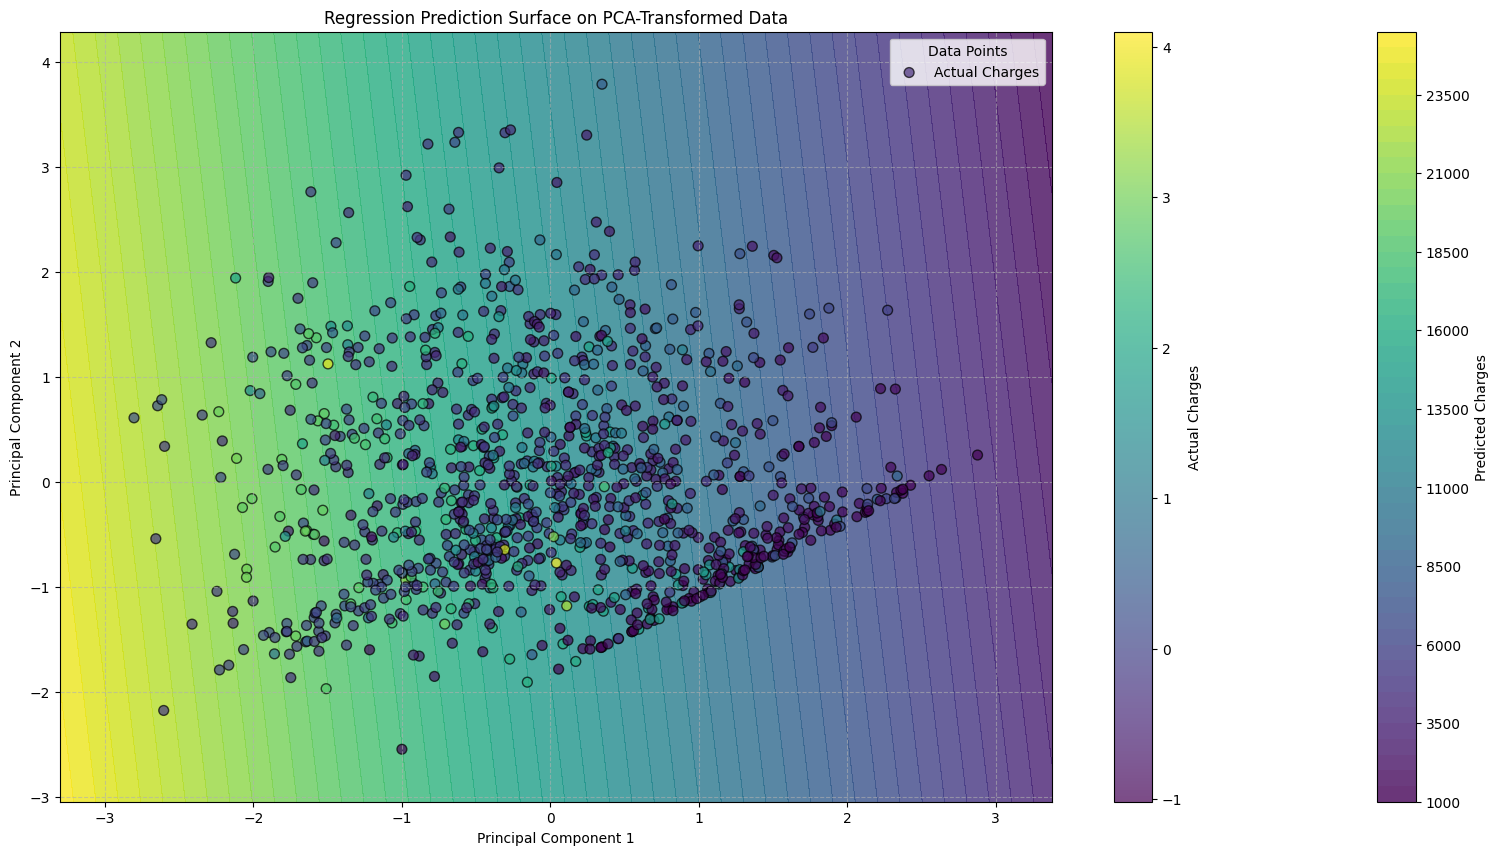

In [ ]:
print("\n--- Visualizing Regression Prediction Surface ---")

x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted_original = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).flatten()
Z_predicted = Z_predicted_original.reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Hypersurfaces Visualization 3D (TensorFlow custom functions)**


--- Visualizing Regression Prediction Surface (3D) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


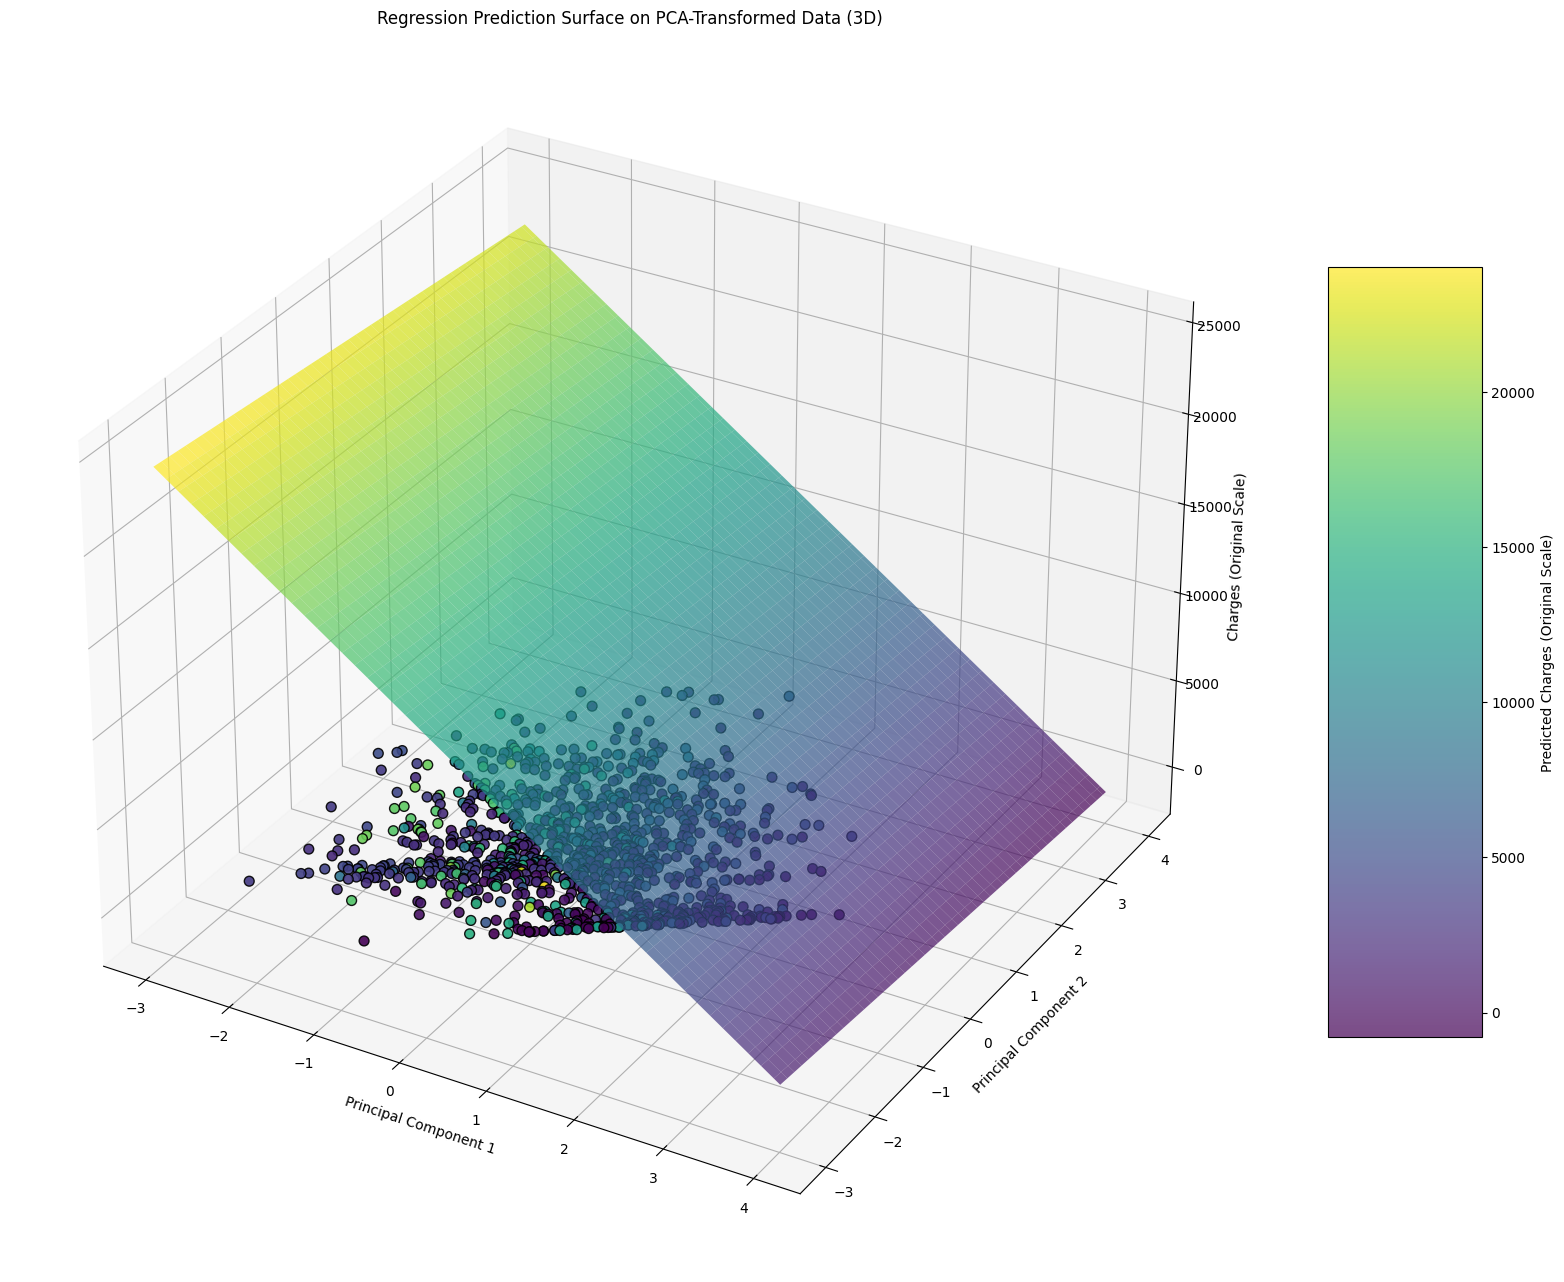

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0
y_min, y_max = -3.0, 4.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_train[:, 0], x_train[:, 1], y_train, c=y_train, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Data (3D)")
plt.show()

**Interpretation of Visualization Results**

The visualization of the regression results confirms the structural limitations imposed by the single linear layer, identical to the previous analysis.

- Prediction Surface (3D): The model's output in the 2D feature space (PC1 and PC2) remains a flat, continuous hyperplane. This hyperplane represents the model's linear approximation of the target charge values.
- Data Clusters vs. Linear Fit: The visualization clearly shows the data points clustered into two distinct groups, one corresponding to low charges (predominantly in the negative PC1 region) and another corresponding to high charges (in the positive PC1 region). The single linear hyperplane attempts to fit both groups simultaneously.
- Inadequate Modeling: The result is a fundamental failure to capture the non-linear relationship between the features and the target variable. The hyperplane necessarily averages the high-charge and low-charge regions, leading to large prediction errors for data points near the transition boundary or deep within the high-charge cluster. The linear model's complexity is insufficient to model the underlying piecewise linear or non-linear nature of the insurance charge data.

# Model Evaluation

This section details the theoretical approach to evaluating a machine learning model, particularly a Perceptron model used for regression, and provides a summary interpretation of the computed metrics and the resulting prediction visualization on the test dataset.

**Regression Evaluation Concepts**

Model evaluation involves quantifying the predictive accuracy of a trained model on a separate test dataset (unseen data). This ensures the metrics accurately reflect the model's ability to generalize beyond the training examples.

- Prediction and Scaling: The final model is used to generate predictions on the PCA-transformed test features. Since the target variable was scaled during preprocessing, the predictions are immediately inverse transformed back to their original dollar units. This step is crucial because the final metrics must be reported in a meaningful, unscaled context.
- Regression Metrics: Several standard metrics are calculated to assess the model's performance:
- Mean Squared Error (MSE): Calculates the average of the squared errors ($\frac{1}{n} \sum (\text{actual} - \text{predicted})^2$). This metric is highly sensitive to large errors or outliers.
- Root Mean Squared Error (RMSE): The square root of the MSE. It provides an error value in the same units as the target variable, offering a more interpretable sense of the average magnitude of prediction error.
- Mean Absolute Error (MAE): Calculates the average of the absolute differences ($\frac{1}{n} \sum |\text{actual} - \text{predicted}|$). MAE is less sensitive to outliers than MSE, giving a clearer picture of the typical prediction deviation.
- R-squared ($R^2$) Score: A statistical measure of how well the predictions approximate the real data points. It ranges from $-\infty$ to $1.0$, where $1.0$ indicates a perfect fit, $0.0$ indicates the model is no better than simply predicting the mean, and negative values indicate a fit significantly worse than predicting the mean.

**Regression Metrics Evaluation**

In [ ]:
print(f"\n--- Regression Metrics on Test Data ---")

y_pred_test_scaled = model.predict(x_test).flatten()

y_pred_test_original = y_scaler.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).flatten()

y_test_original = y_test.values.flatten()

mse = mean_squared_error(y_test_original, y_pred_test_original)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_original, y_pred_test_original)
mae = mean_absolute_error(y_test_original, y_pred_test_original)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print("-" * 30)


--- Regression Metrics on Test Data ---
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Mean Squared Error (MSE): 194875568.5815
Root Mean Squared Error (RMSE): 13959.7840
Mean Absolute Error (MAE): 13509.0131
R-squared (R2): -181174404.5451
------------------------------


**Regression Hypersurfaces 2D (Test Dataset)**

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


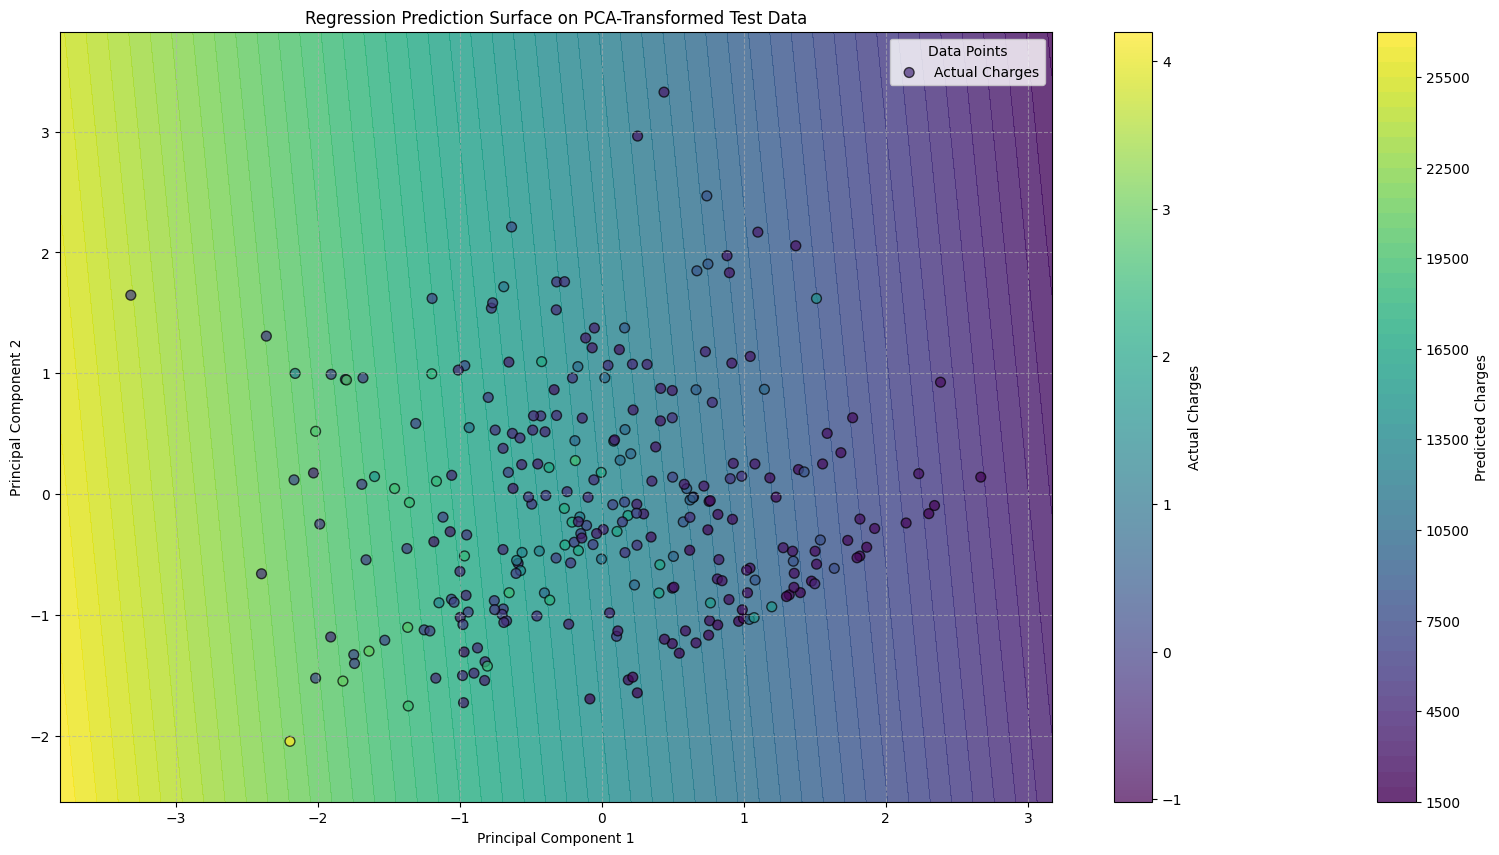

In [ ]:
x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted_original = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).flatten()
Z_predicted = Z_predicted_original.reshape(xx.shape)

plt.figure(figsize=(20, 10))

contour = plt.contourf(xx, yy, Z_predicted, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Predicted Charges')

scatter = plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap='viridis', edgecolors='k', s=50, alpha=0.7, label='Actual Charges')
plt.colorbar(scatter, label='Actual Charges')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Regression Prediction Surface on PCA-Transformed Test Data")
plt.legend(title="Data Points")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Regression Hypersurfaces 3D (Test Dataset)**


--- Visualizing Regression Prediction Surface (3D) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


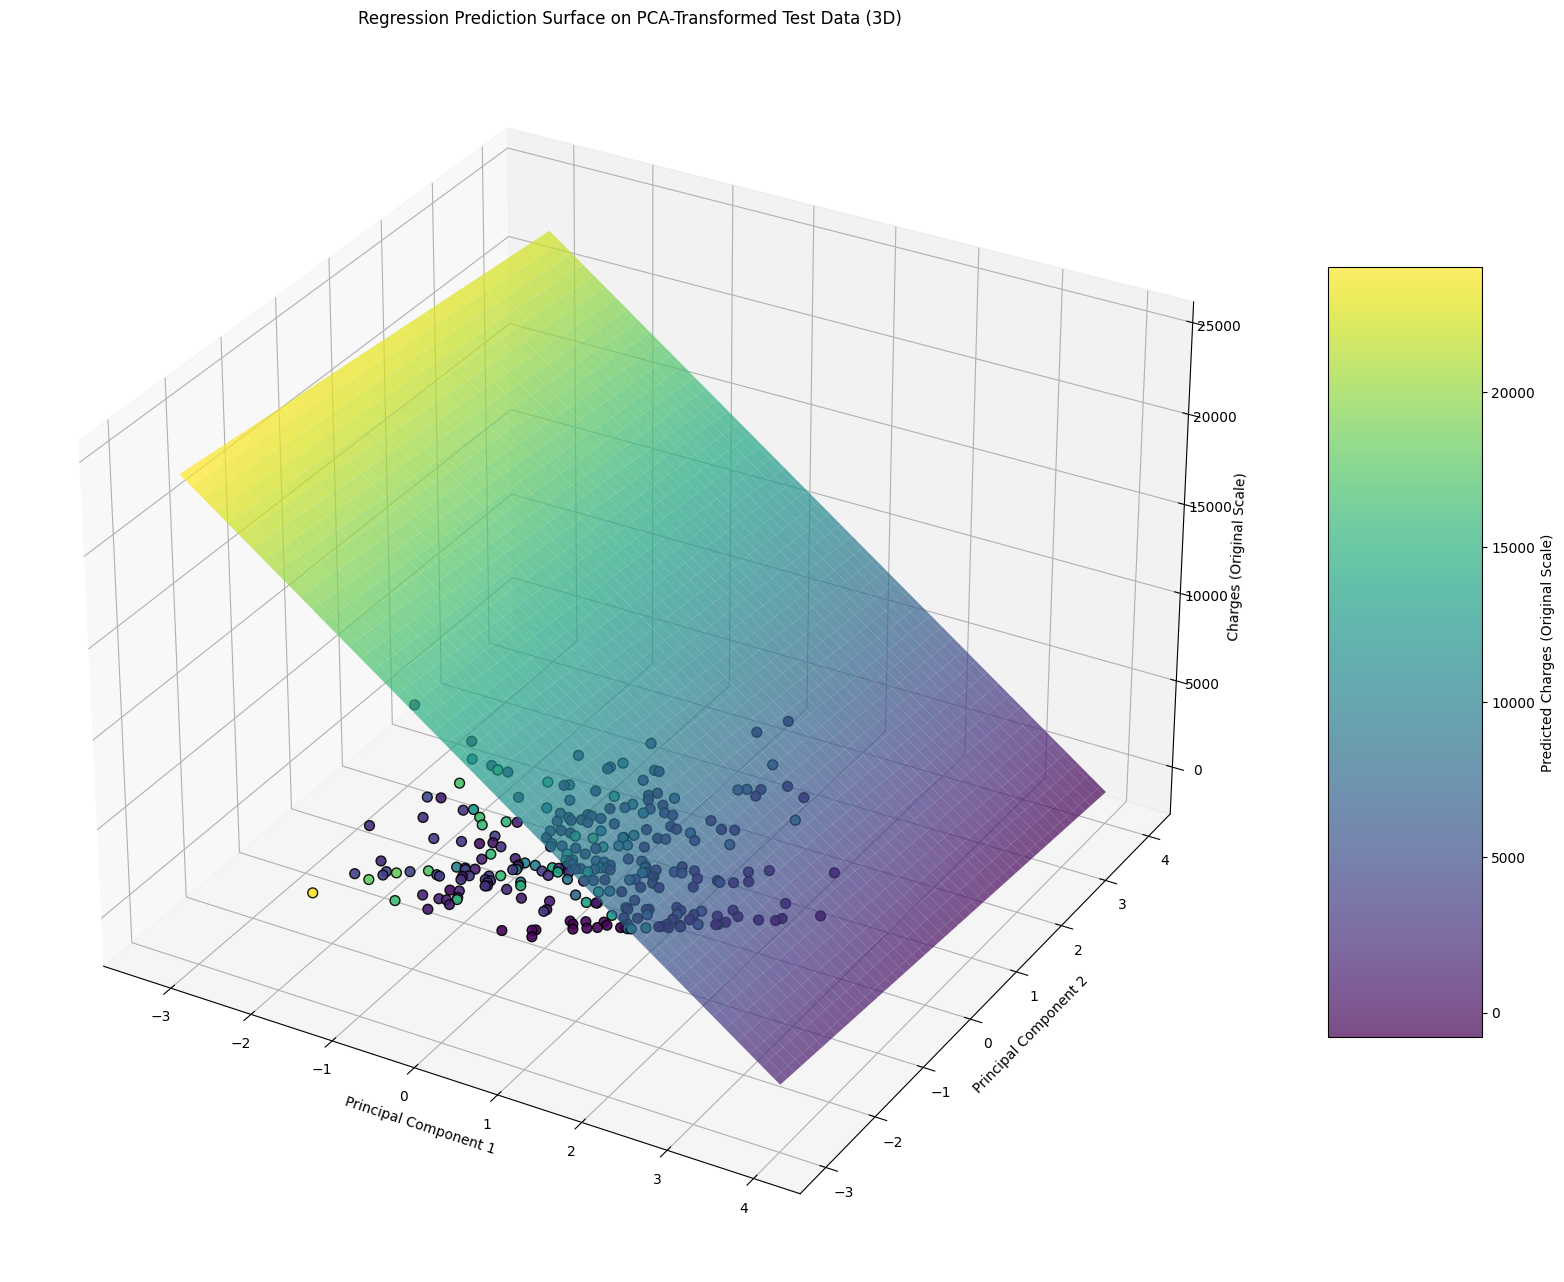

In [ ]:
print("\n--- Visualizing Regression Prediction Surface (3D) ---")

x_min, x_max = -3.0, 4.0
y_min, y_max = -3.0, 4.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

meshgrid_points = np.c_[xx.ravel(), yy.ravel()]

Z_predicted_scaled = model.predict(meshgrid_points).flatten()

Z_predicted = y_scaler.inverse_transform(Z_predicted_scaled.reshape(-1, 1)).reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(xx, yy, Z_predicted, cmap='viridis', alpha=0.7)
fig.colorbar(surface, shrink=0.5, aspect=5, label='Predicted Charges (Original Scale)')

ax.scatter(x_test[:, 0], x_test[:, 1], y_test, c=y_test, cmap='viridis', edgecolors='k', s=50, alpha=0.9, label='Actual Charges')

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Charges (Original Scale)")
ax.set_title("Regression Prediction Surface on PCA-Transformed Test Data (3D)")
plt.show()

**Interpretation of Visualization Results**

The visualizations of the prediction surface on the test data reinforce the conclusions drawn from the numerical metrics.

- Linear Surface Constraint: Both the 2D contour plot and the 3D surface plot show a fixed, linear hyperplane. Since the Perceptron only performs a linear transformation, the prediction surface must be flat, regardless of the complexity of the data it attempts to model.
- Data Mismatch: The actual test data points, visible in both plots, clearly follow a non-linear, two-cluster pattern: a large cluster with low charges and a smaller cluster with high charges. The linear hyperplane attempts to cut through the middle of these distinct groups.
- Conclusion: The visualization confirms that the model is fundamentally underfitting the data. The simple linear capacity of the Perceptron is incapable of distinguishing between the two major clusters or following the sharp increase in charges seen in the higher PC1 region, leading directly to the highly negative $R^2$ score and massive prediction errors.

# Conclusion

The project successfully demonstrates the implementation of a fundamental linear model—the Perceptron—within the Keras framework using custom components. The pipeline confirms that proper data standardization and dimensionality reduction are non-negotiable prerequisites for neural network training. The most significant finding derived from the evaluation and visualization is the confirmation of the model's linear constraint. The simple Perceptron is fundamentally incapable of modeling the complex, non-linear relationships inherent in the insurance charges dataset, necessitating the adoption of more sophisticated, non-linear architectures for effective prediction.

# References

- [What is Perceptron | The Simplest Artificial neural network](https://www.geeksforgeeks.org/machine-learning/what-is-perceptron-the-simplest-artificial-neural-network/)
- [Perceptron Wikipedia](https://en.wikipedia.org/wiki/Perceptron)
- [Perceptron: Building Block of Artificial Neural Network](https://www.analyticsvidhya.com/blog/2021/10/perceptron-building-block-of-artificial-neural-network/)
- [Single Layer Perceptron in TensorFlow](https://www.geeksforgeeks.org/python/single-layer-perceptron-in-tensorflow/)
- [Perceptrons Research Paper](https://www.researchgate.net/publication/300873533_Perceptrons)
- [TensorFlow: single-layer perceptron from zero](https://www.kaggle.com/code/rafaelleonhardt/tensorflow-single-layer-perceptron-from-zero)